# EDA cấu trúc bảng M1/M2

Theo dõi từng ảnh trung gian để hiểu cách baseline biến pixel thành hàng, cột và crop ô.

## 1. Chuẩn bị

Nạp thư viện, tìm thư mục dữ liệu và chọn một tài liệu để quan sát.

In [1]:
import json
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np

ROOT = Path.cwd().resolve().parent
assert (ROOT / 'data/training_set/manifest.jsonl').is_file(), 'Không tìm thấy data/training_set; mở notebook từ thư mục Doc2Table/notebooks.'
TRAIN_DIR = ROOT / 'data' / 'training_set'

# Mẫu M2; ảnh gốc thẳng nên tạo nghiêng 2° để quan sát deskew.
SAMPLE_ID = 'train-00300'
PAGE_INDEX = 0  # Trang 1, vì Python đếm từ 0
DEMO_SKEW_DEGREES = 2.0

records = [json.loads(line) for line in (TRAIN_DIR / 'manifest.jsonl').read_text(encoding='utf-8').splitlines()]
record = next(row for row in records if row['id'] == SAMPLE_ID)
image_path = TRAIN_DIR / record['image_paths'][PAGE_INDEX]
label_path = TRAIN_DIR / record['page_label_paths'][PAGE_INDEX]

print('ROOT       :', ROOT.resolve())
print('ID         :', record['id'])
print('Trang      :', PAGE_INDEX + 1, '/', record['page_count'])
print('Ảnh        :', image_path.name)
print('Độ khó     :', record['difficulty'])
print('Thuộc tính :', record['attributes'])

ROOT       : E:\AIO\Project\olp-ai-ptit-2026-preliminary-round\Doc2Table
ID         : train-00300
Trang      : 1 / 1
Ảnh        : train-00300_p01.jpg
Độ khó     : M2
Thuộc tính : {'border_mode': 'grid', 'has_bold': True, 'has_escaped_pipe': False, 'has_merge': True, 'has_multiline': True, 'long_table_crosses_pages': False, 'max_columns': 9, 'max_data_rows': 13, 'page_count': 1, 'spans_two_pages': False, 'table_count': 1}


## 2. Ảnh gốc và nhãn chuẩn

Ảnh là đầu vào của mô hình; nhãn Markdown cho biết cấu trúc đúng cần khôi phục.

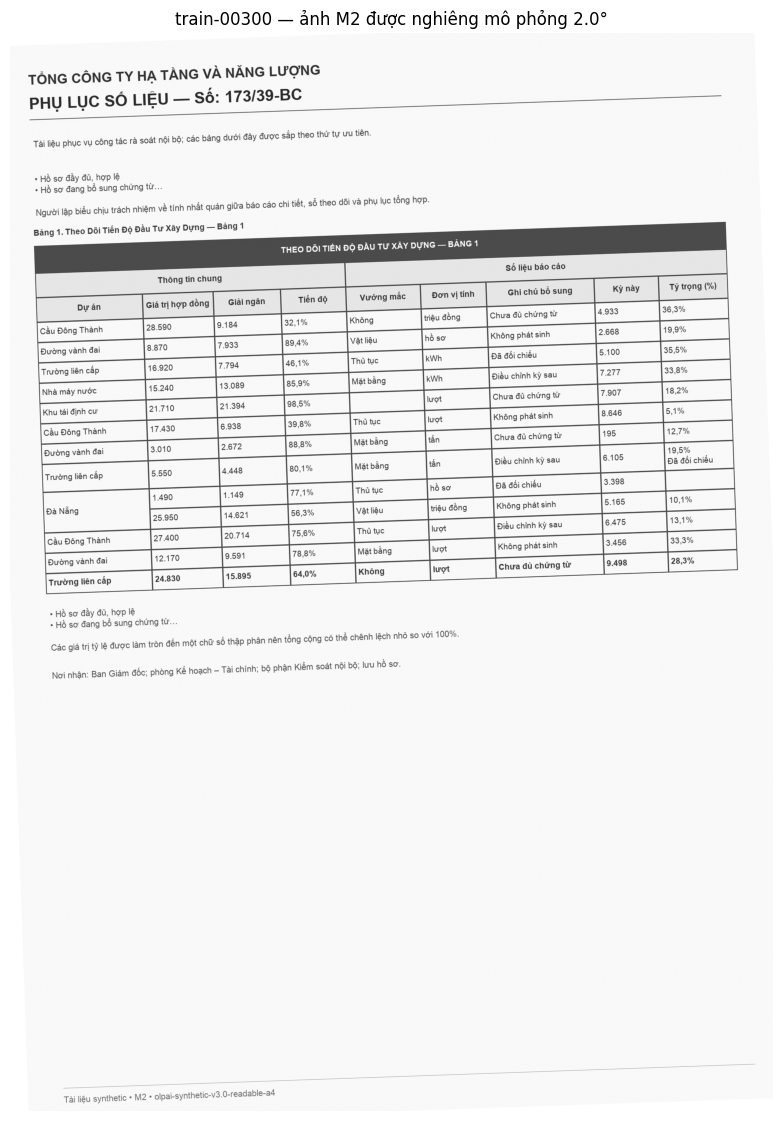

| **THEO DÕI TIẾN ĐỘ ĐẦU TƯ XÂY DỰNG — BẢNG 1** | [[H]] | [[H]] | [[H]] | [[H]] | [[H]] | [[H]] | [[H]] | [[H]] |
| --- | --- | --- | --- | --- | --- | --- | --- | --- |
| **Thông tin chung** | [[H]] | [[H]] | [[H]] | **Số liệu báo cáo** | [[H]] | [[H]] | [[H]] | [[H]] |
| **Dự án** | **Giá trị hợp đồng** | **Giải ngân** | **Tiến độ** | **Vướng mắc** | **Đơn vị tính** | **Ghi chú bổ sung** | **Kỳ này** | **Tỷ trọng (%)** |
| Cầu Đông Thành | 28.590 | 9.184 | 32,1% | Không | triệu đồng | Chưa đủ chứng từ | 4.933 | 36,3% |
| Đường vành đai | 8.870 | 7.933 | 89,4% | Vật liệu | hồ sơ | Không phát sinh | 2.668 | 19,9% |
| Trường liên cấp | 16.920 | 7.794 | 46,1% | Thủ tục | kWh | Đã đối chiếu | 5.100 | 35,5% |
| Nhà máy nước | 15.240 | 13.089 | 85,9% | Mặt bằng | kWh | Điều chỉnh kỳ sau | 7.277 | 33,8% |
| Khu tái định cư | 21.710 | 21.394 | 98,5% |  | lượt | Chưa đủ chứng từ | 7.907 | 18,2% |
| Cầu Đông Thành | 17.430 | 6.938 | 39,8% | Thủ tục | lượt | Không phát sinh | 8.646 | 5,1% |
| Đư

In [2]:
original_gray = cv2.imread(str(image_path), cv2.IMREAD_GRAYSCALE)
assert original_gray is not None, f'Không đọc được ảnh: {image_path}'
height, width = original_gray.shape
demo_matrix = cv2.getRotationMatrix2D((width / 2, height / 2), DEMO_SKEW_DEGREES, 1.0)
gray = cv2.warpAffine(
    original_gray, demo_matrix, (width, height),
    flags=cv2.INTER_CUBIC, borderMode=cv2.BORDER_CONSTANT, borderValue=255,
)

plt.figure(figsize=(10, 14))
plt.imshow(gray, cmap='gray')
plt.title(f'{SAMPLE_ID} — ảnh M2 được nghiêng mô phỏng {DEMO_SKEW_DEGREES}°')
plt.axis('off')
plt.show()

print(label_path.read_text(encoding='utf-8'))

## 3. Làm thẳng ảnh

Quan sát riêng từng bước: Canny, Hough, lọc góc và xoay ảnh.

### 3.1. Phát hiện cạnh bằng Canny

Canny giữ lại nơi độ sáng thay đổi mạnh, gồm biên chữ và mép đường kẻ.

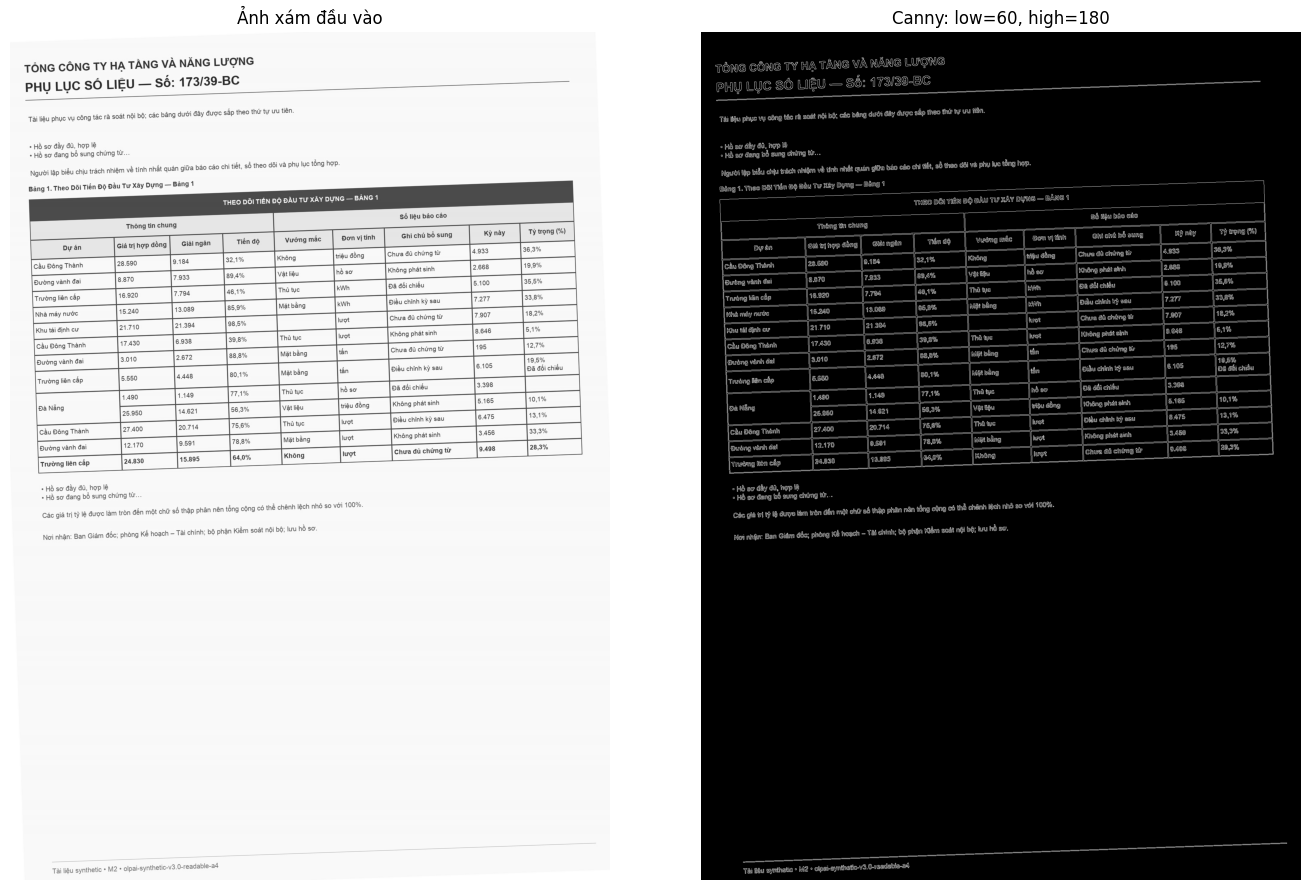

Kích thước mask: (2546, 1800)
Số pixel cạnh: 152350


In [3]:
CANNY_LOW = 60
CANNY_HIGH = 180
canny_edges_step = cv2.Canny(gray, CANNY_LOW, CANNY_HIGH)

fig, axes = plt.subplots(1, 2, figsize=(14, 9))
axes[0].imshow(gray, cmap='gray')
axes[0].set_title('Ảnh xám đầu vào')
axes[1].imshow(canny_edges_step, cmap='gray')
axes[1].set_title(f'Canny: low={CANNY_LOW}, high={CANNY_HIGH}')
for ax in axes: ax.axis('off')
plt.tight_layout()
plt.show()
print('Kích thước mask:', canny_edges_step.shape)
print('Số pixel cạnh:', np.count_nonzero(canny_edges_step))

#### Input → output thô của Canny

Canny nhận ma trận ảnh xám và trả về ma trận cùng kích thước, trong đó mỗi pixel là 0 hoặc 255.

In [4]:
edge_points = np.argwhere(canny_edges_step > 0)
assert len(edge_points), 'Canny không tìm thấy cạnh.'
center = np.array(gray.shape) / 2
edge_y, edge_x = edge_points[np.argmin(np.sum((edge_points - center) ** 2, axis=1))]
ys = slice(max(0, edge_y-3), edge_y+4)
xs = slice(max(0, edge_x-7), edge_x+8)
gray_patch = gray[ys, xs]
edge_patch = canny_edges_step[ys, xs]

print('Cùng một vùng quanh cạnh tại (y, x) =', (edge_y, edge_x))
print('\nINPUT gray — độ sáng 0..255:\n', gray_patch)
print('\nOUTPUT Canny — 255 là cạnh, 0 là không phải cạnh:\n', edge_patch)
print('\nToàn mảng:', gray.shape, gray.dtype, '→', canny_edges_step.shape, canny_edges_step.dtype)

Cùng một vùng quanh cạnh tại (y, x) = (np.int64(1273), np.int64(882))

INPUT gray — độ sáng 0..255:
 [[123 255 250 252 145  46  71 189 251 252 250 247 248 249 249]
 [164 253 249 250 195  47  67 182 252 252 246 252 247 249 249]
 [158 255 244 246 204  49  63 175 253 250 249 250 251 249 249]
 [139 252 247 251 183  54  57 174 249 249 250 247 250 249 249]
 [ 82 239 255 240 121  61  45 177 245 252 246 250 246 249 249]
 [ 50 127 201 155  57  53  55 167 240 252 247 252 249 249 249]
 [ 68  45  41  53 110  55  62 161 240 251 250 249 251 249 249]]

OUTPUT Canny — 255 là cạnh, 0 là không phải cạnh:
 [[255   0   0   0 255   0   0 255   0   0   0   0   0   0   0]
 [255   0   0   0 255   0   0 255   0   0   0   0   0   0   0]
 [255   0   0   0 255   0   0 255   0   0   0   0   0   0   0]
 [255   0   0   0 255   0   0 255   0   0   0   0   0   0   0]
 [255 255   0 255 255   0   0 255   0   0   0   0   0   0   0]
 [  0 255 255 255   0   0   0 255   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0  

### 3.2. Tìm đoạn thẳng bằng HoughLinesP

Mỗi đoạn đỏ là một ứng viên `(x0, y0, x1, y1)` được ghép từ các pixel cạnh.

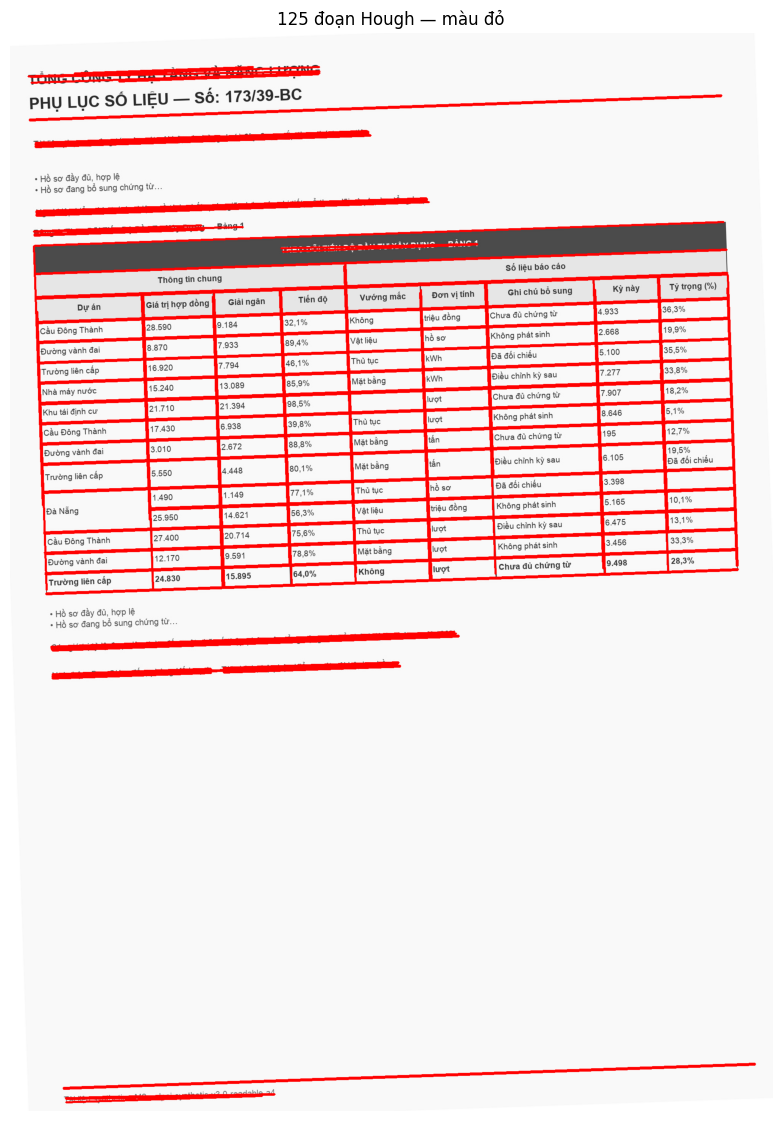

threshold = 150
minLineLength = 360
maxLineGap = 22
5 đoạn đầu:
 [[  69  877 1701  820]
 [  67  828 1699  771]
 [  81 1227 1713 1170]
 [  62  682 1694  625]
 [  83 1278 1715 1221]]


In [5]:
height_step, width_step = gray.shape
hough_threshold = max(70, width_step // 12)
min_line_length = max(180, width_step // 5)
max_line_gap = max(12, width_step // 80)

hough_result = cv2.HoughLinesP(
    canny_edges_step, rho=1, theta=np.pi / 1800,
    threshold=hough_threshold, minLineLength=min_line_length,
    maxLineGap=max_line_gap,
)
raw_lines = (np.asarray(hough_result).reshape(-1, 4)
             if hough_result is not None else np.empty((0, 4), dtype=int))

hough_overlay = cv2.cvtColor(gray, cv2.COLOR_GRAY2RGB)
for x0, y0, x1, y1 in raw_lines:
    cv2.line(hough_overlay, (x0, y0), (x1, y1), (255, 0, 0), 3)

plt.figure(figsize=(10, 14))
plt.imshow(hough_overlay)
plt.title(f'{len(raw_lines)} đoạn Hough — màu đỏ')
plt.axis('off')
plt.show()
print('threshold =', hough_threshold)
print('minLineLength =', min_line_length)
print('maxLineGap =', max_line_gap)
print('5 đoạn đầu:\n', raw_lines[:5])

#### Input → output thô của Hough

Hough nhận mask nhị phân và trả về mảng các đoạn thẳng, mỗi đoạn gồm hai đầu mút.

In [6]:
print('INPUT canny_edges_step')
print('  shape:', canny_edges_step.shape, '| dtype:', canny_edges_step.dtype)
print('  pixel cạnh:', np.count_nonzero(canny_edges_step))

print('\nOUTPUT gốc của cv2.HoughLinesP')
print('  type :', type(hough_result))
print('  shape:', None if hough_result is None else hough_result.shape)
print('  5 phần tử đầu:\n', None if hough_result is None else hough_result[:5])

print('\nOUTPUT sau reshape(-1, 4)')
print('  shape:', raw_lines.shape, '| dtype:', raw_lines.dtype)
print('  mỗi hàng = [x0, y0, x1, y1]\n', raw_lines[:5])

INPUT canny_edges_step
  shape: (2546, 1800) | dtype: uint8
  pixel cạnh: 152350

OUTPUT gốc của cv2.HoughLinesP
  type : <class 'numpy.ndarray'>
  shape: (125, 4)
  5 phần tử đầu:
 [[  69  877 1701  820]
 [  67  828 1699  771]
 [  81 1227 1713 1170]
 [  62  682 1694  625]
 [  83 1278 1715 1221]]

OUTPUT sau reshape(-1, 4)
  shape: (125, 4) | dtype: int32
  mỗi hàng = [x0, y0, x1, y1]
 [[  69  877 1701  820]
 [  67  828 1699  771]
 [  81 1227 1713 1170]
 [  62  682 1694  625]
 [  83 1278 1715 1221]]


### 3.3. Tính và lọc góc

Đường xanh nằm trong ±4° và được giữ; đường đỏ không tham gia tính góc deskew.

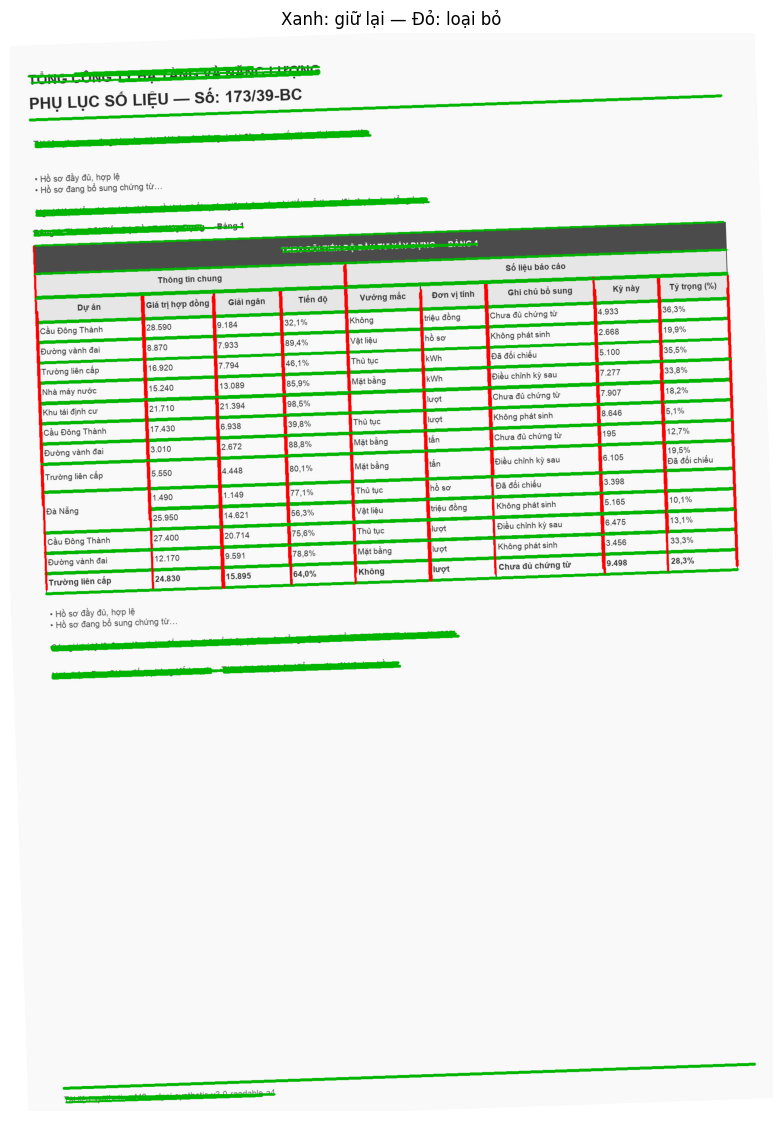

Giữ 103/125 đoạn
10 góc đầu: [-2.0003 -2.0003 -2.0003 -2.0003 -2.0003 -2.0003 -2.0003 -1.9737 -2.0003
 -2.0003]


In [7]:
maximum_degrees_step = 4.0
angles_step = []
angle_rows = []
filtered_overlay = cv2.cvtColor(gray, cv2.COLOR_GRAY2RGB)

for x0, y0, x1, y1 in raw_lines:
    current_angle = float(np.degrees(np.arctan2(y1 - y0, x1 - x0)))
    while current_angle > 90:
        current_angle -= 180
    while current_angle < -90:
        current_angle += 180
    accepted = abs(current_angle) <= maximum_degrees_step
    angle_rows.append((current_angle, accepted))
    color = (0, 180, 0) if accepted else (255, 0, 0)
    cv2.line(filtered_overlay, (x0, y0), (x1, y1), color, 3)
    if accepted:
        angles_step.append(current_angle)

plt.figure(figsize=(10, 14))
plt.imshow(filtered_overlay)
plt.title('Xanh: giữ lại — Đỏ: loại bỏ')
plt.axis('off')
plt.show()
print(f'Giữ {len(angles_step)}/{len(raw_lines)} đoạn')
print('10 góc đầu:', np.round(angles_step[:10], 4))

### 3.4. Chọn góc đại diện và xoay ảnh

Lấy trung vị các góc hợp lệ; chỉ xoay khi độ nghiêng từ 0,08° trở lên.

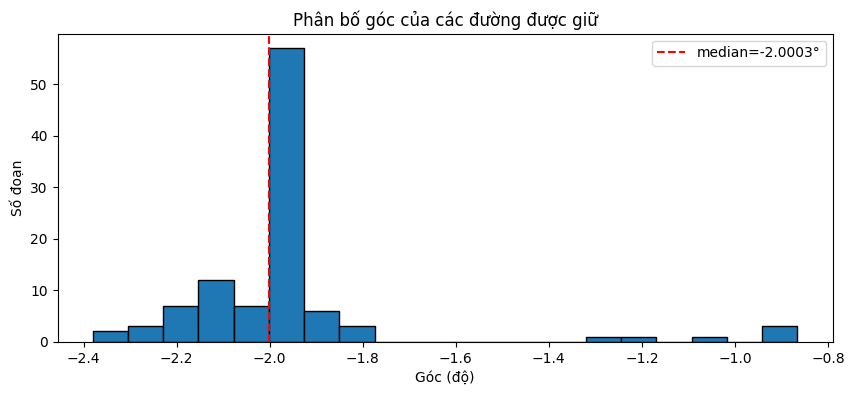

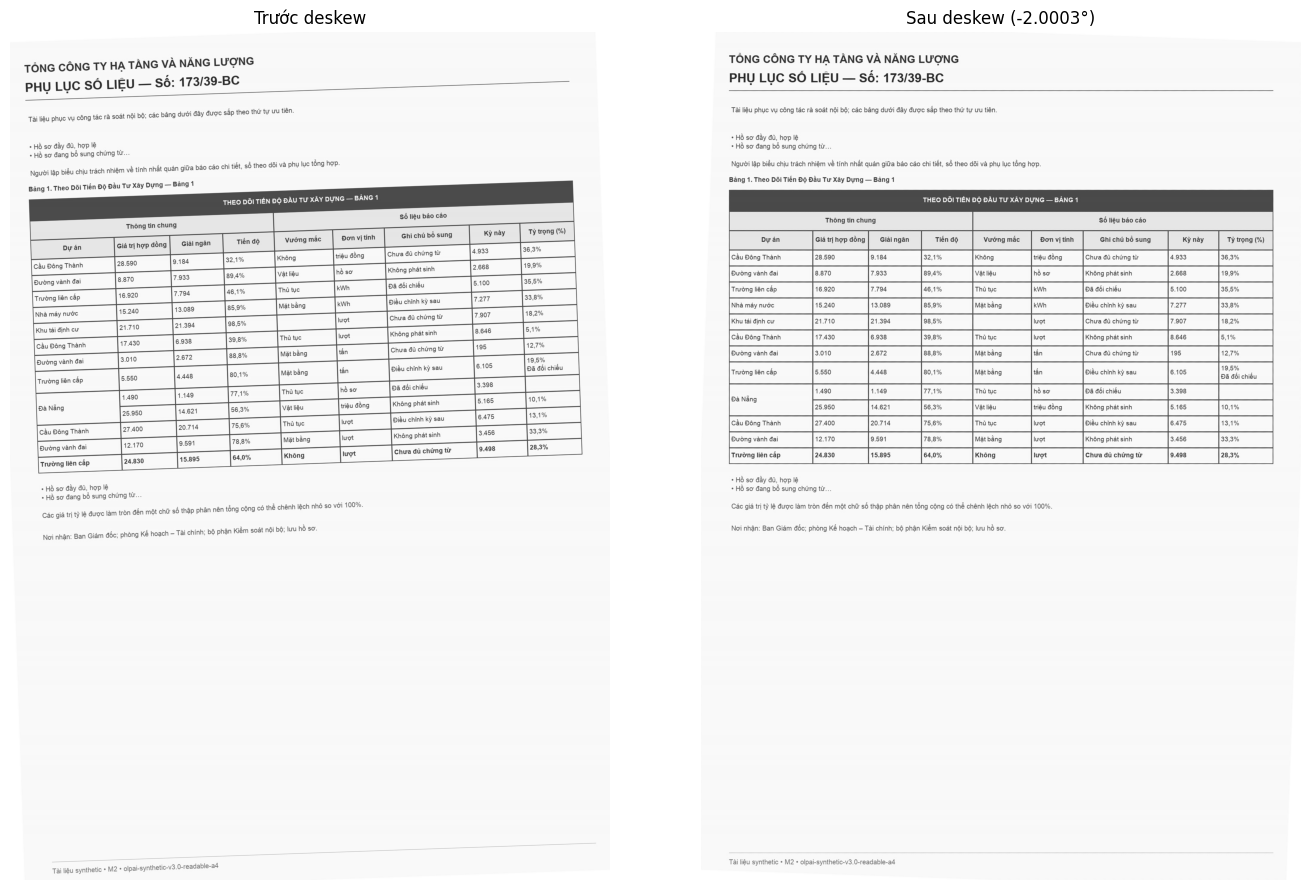

Đã xoay -2.0003°.
Ma trận xoay:
 [[ 9.99390628e-01 -3.49051874e-02  4.49827381e+01]
 [ 3.49051874e-02  9.99390628e-01 -3.06389384e+01]]


In [8]:
angle_step = float(np.median(angles_step)) if angles_step else 0.0

if angles_step:
    plt.figure(figsize=(10, 4))
    plt.hist(angles_step, bins=min(20, max(5, len(angles_step))), edgecolor='black')
    plt.axvline(angle_step, color='red', linestyle='--', label=f'median={angle_step:.4f}°')
    plt.title('Phân bố góc của các đường được giữ')
    plt.xlabel('Góc (độ)')
    plt.ylabel('Số đoạn')
    plt.legend()
    plt.show()

if abs(angle_step) < 0.08:
    deskewed_step = gray.copy()
    rotation_matrix_step = None
    decision = 'Không xoay vì góc quá nhỏ.'
else:
    center_step = (width_step / 2, height_step / 2)
    rotation_matrix_step = cv2.getRotationMatrix2D(center_step, angle_step, 1.0)
    deskewed_step = cv2.warpAffine(
        gray, rotation_matrix_step, (width_step, height_step),
        flags=cv2.INTER_CUBIC, borderMode=cv2.BORDER_CONSTANT, borderValue=255,
    )
    decision = f'Đã xoay {angle_step:.4f}°.'

fig, axes = plt.subplots(1, 2, figsize=(14, 9))
axes[0].imshow(gray, cmap='gray'); axes[0].set_title('Trước deskew')
axes[1].imshow(deskewed_step, cmap='gray'); axes[1].set_title(f'Sau deskew ({angle_step:.4f}°)')
for ax in axes: ax.axis('off')
plt.tight_layout()
plt.show()
print(decision)
print('Ma trận xoay:\n', rotation_matrix_step)

### 3.5. Hàm baseline hoàn chỉnh

Cell dưới giữ nguyên hàm ban đầu để đối chiếu; kết quả phải trùng với các bước vừa tách.

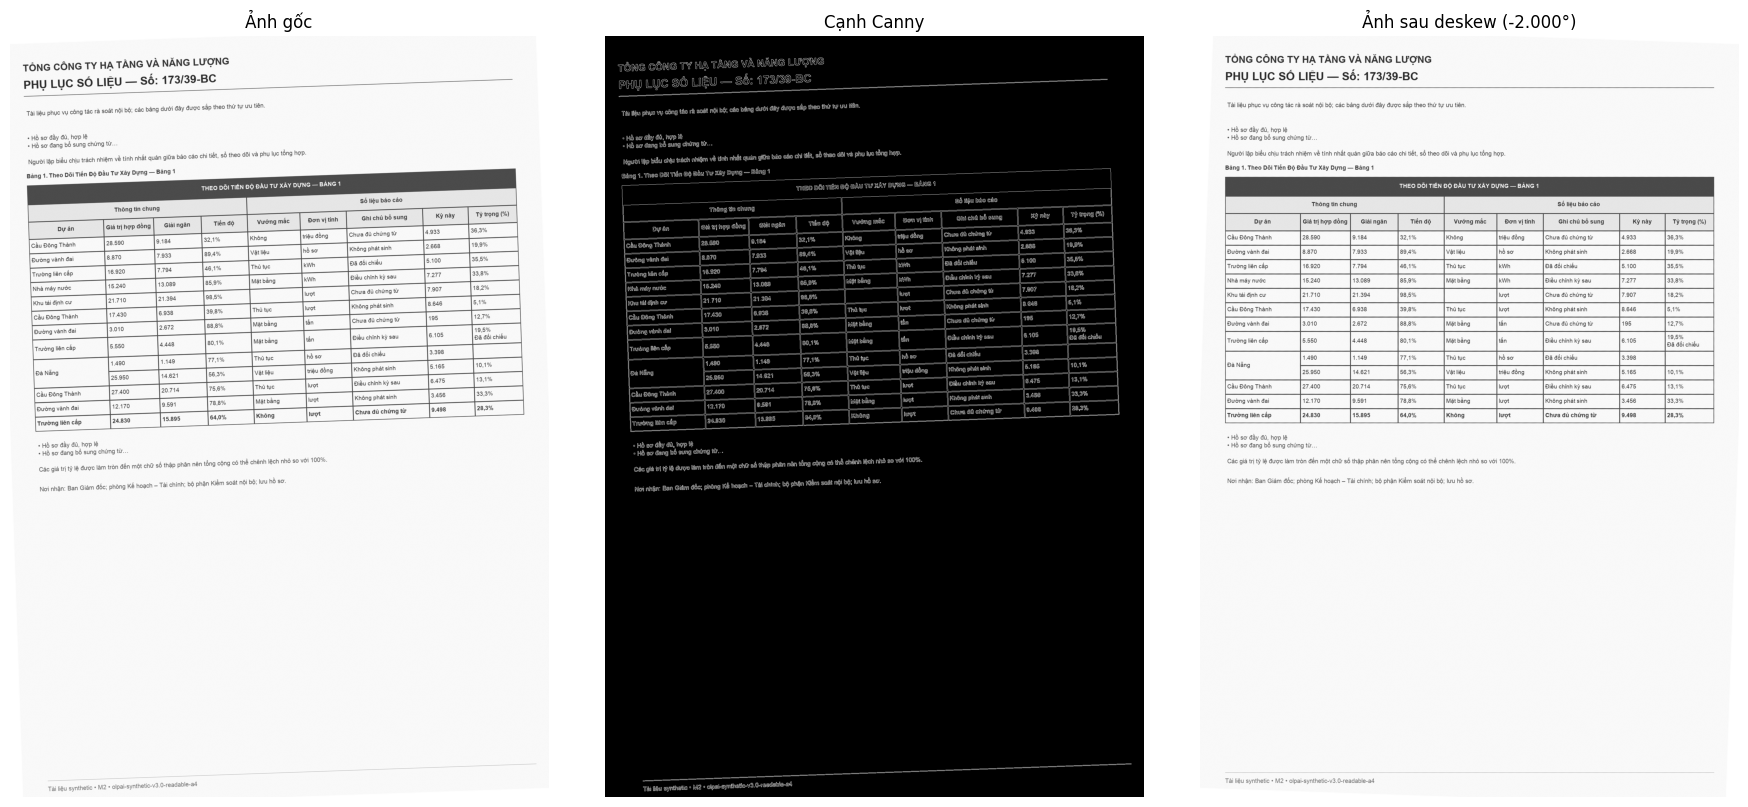

In [9]:
def deskew_gray(image, maximum_degrees=4.0):
    edges = cv2.Canny(image, 60, 180)
    height, width = image.shape
    lines = cv2.HoughLinesP(
        edges, 1, np.pi / 1800, threshold=max(70, width // 12),
        minLineLength=max(180, width // 5), maxLineGap=max(12, width // 80),
    )
    angles = []
    if lines is not None:
        for x0, y0, x1, y1 in np.asarray(lines).reshape(-1, 4):
            angle = float(np.degrees(np.arctan2(y1 - y0, x1 - x0)))
            while angle > 90: angle -= 180
            while angle < -90: angle += 180
            if abs(angle) <= maximum_degrees:
                angles.append(angle)
    angle = float(np.median(angles)) if angles else 0.0
    if abs(angle) < 0.08:
        return image, angle, edges
    matrix = cv2.getRotationMatrix2D((width / 2, height / 2), angle, 1.0)
    rotated = cv2.warpAffine(image, matrix, (width, height), flags=cv2.INTER_CUBIC, borderValue=255)
    return rotated, angle, edges

deskewed, angle, canny_edges = deskew_gray(gray)
fig, axes = plt.subplots(1, 3, figsize=(18, 8))
for ax, image, title in zip(axes, [gray, canny_edges, deskewed], ['Ảnh gốc', 'Cạnh Canny', f'Ảnh sau deskew ({angle:.3f}°)']):
    ax.imshow(image, cmap='gray')
    ax.set_title(title)
    ax.axis('off')
plt.tight_layout()
plt.show()

## 4. Nhị phân hóa

Tăng tương phản bằng CLAHE rồi đưa ảnh về hai giá trị: nền 0, nét mực 255.

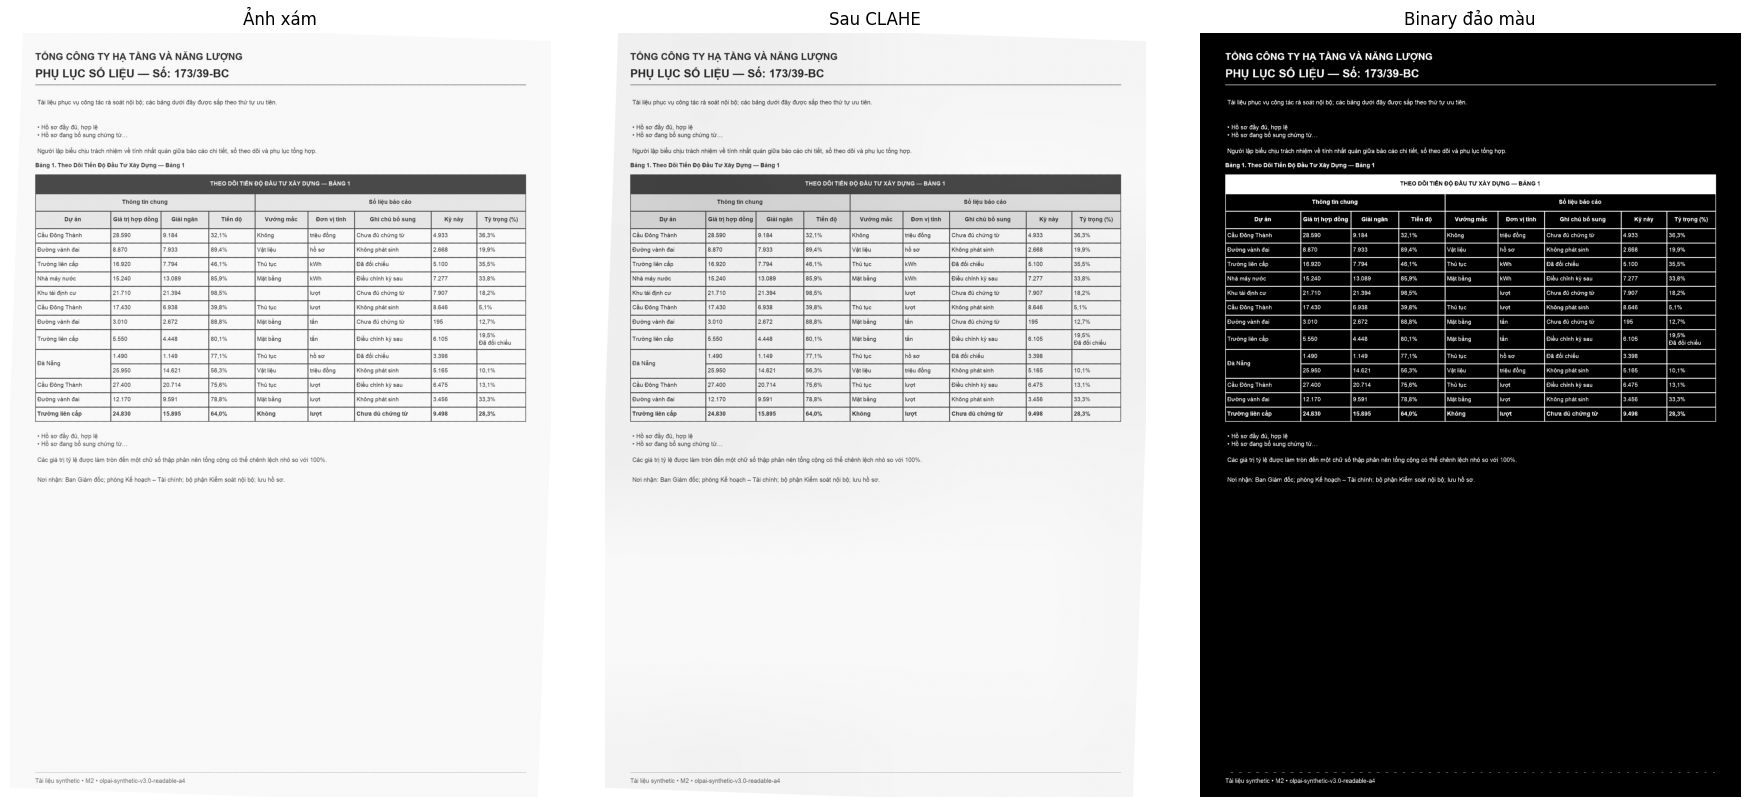

In [10]:
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8)).apply(deskewed)
binary = cv2.threshold(clahe, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)[1]

fig, axes = plt.subplots(1, 3, figsize=(18, 8))
for ax, image, title in zip(axes, [deskewed, clahe, binary], ['Ảnh xám', 'Sau CLAHE', 'Binary đảo màu']):
    ax.imshow(image, cmap='gray')
    ax.set_title(title)
    ax.axis('off')
plt.tight_layout()
plt.show()

## 5. Tách đường ngang và đường dọc

Morphological opening giữ lại nét đủ dài theo một hướng và loại phần lớn chữ.

Kernel ngang: (100, 1)
Kernel dọc  : (1, 56)


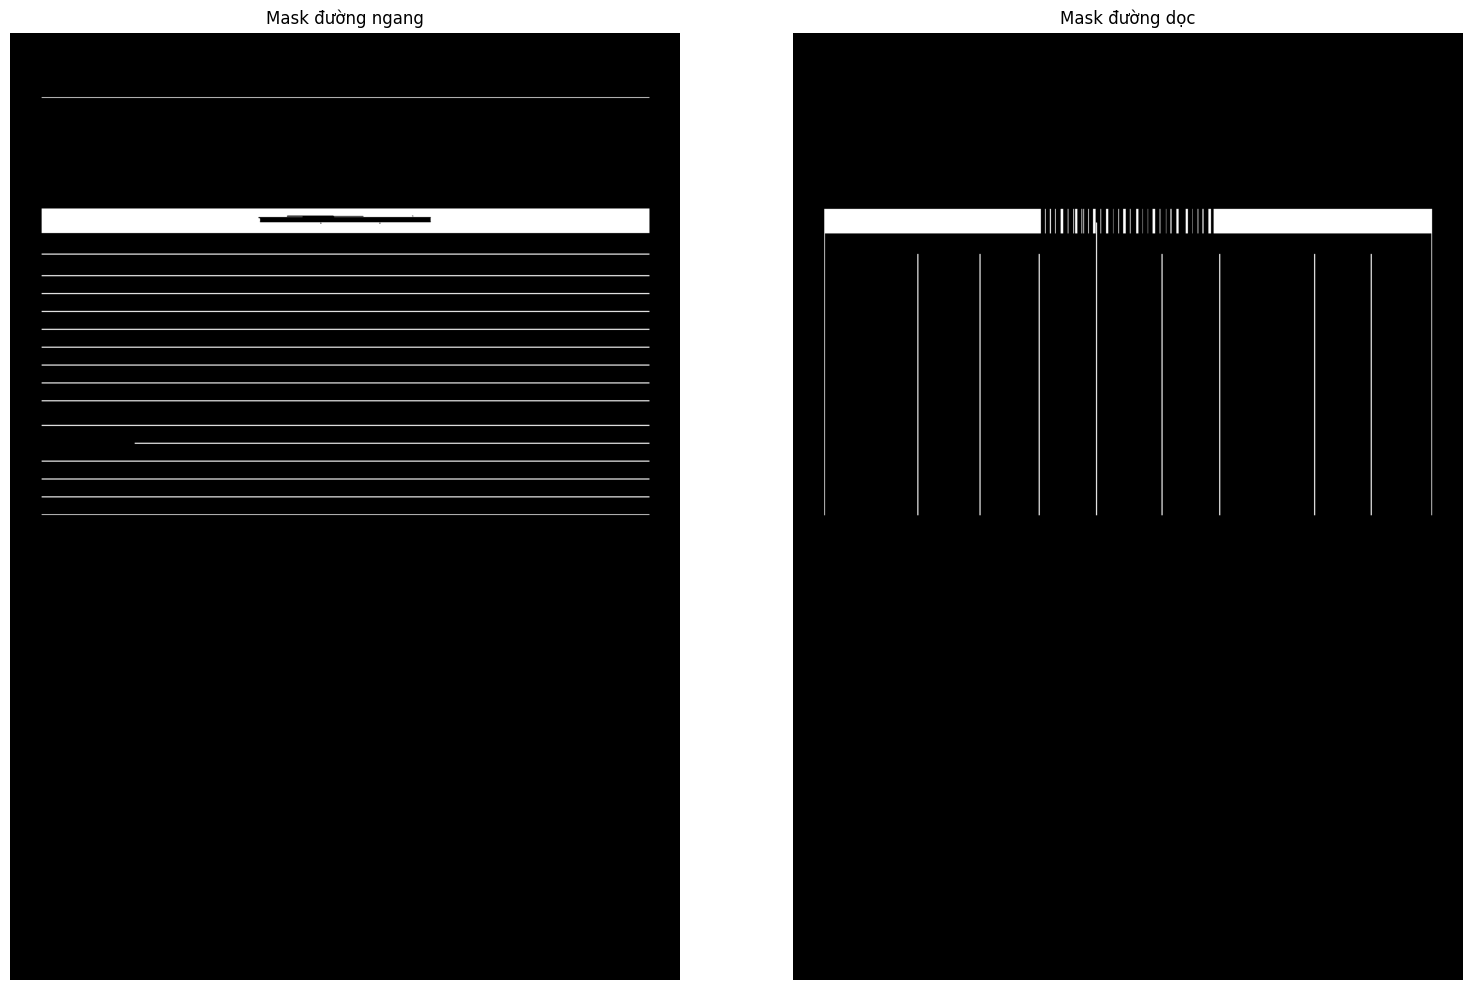

In [11]:
height, width = binary.shape
horizontal_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (max(45, width // 18), 1))
vertical_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (1, max(35, height // 45)))
horizontal = cv2.morphologyEx(binary, cv2.MORPH_OPEN, horizontal_kernel)
vertical = cv2.morphologyEx(binary, cv2.MORPH_OPEN, vertical_kernel)

print('Kernel ngang:', horizontal_kernel.shape[::-1])
print('Kernel dọc  :', vertical_kernel.shape[::-1])
fig, axes = plt.subplots(1, 2, figsize=(16, 10))
for ax, image, title in zip(axes, [horizontal, vertical], ['Mask đường ngang', 'Mask đường dọc']):
    ax.imshow(image, cmap='gray')
    ax.set_title(title)
    ax.axis('off')
plt.tight_layout()
plt.show()

## 6. Tìm vùng bảng

Ghép hai mask, nối các khe hở nhỏ và lấy contour lớn làm ứng viên bảng.

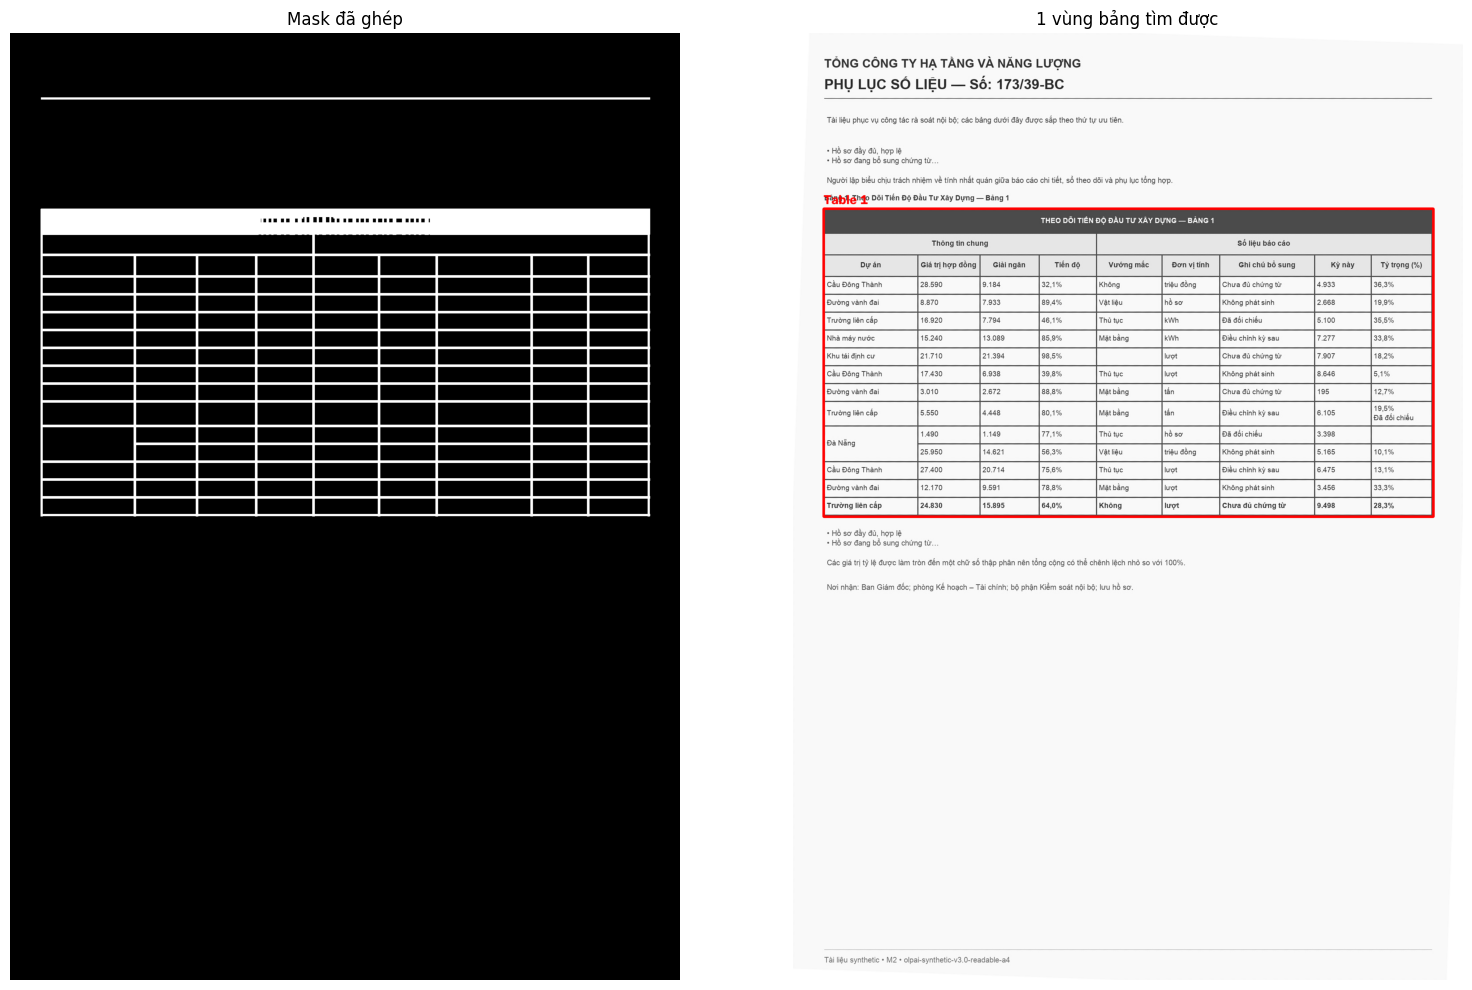

Bounding boxes: [(82, 472, 1720, 1300)]


In [12]:
joined = cv2.dilate(
    cv2.bitwise_or(horizontal, vertical),
    cv2.getStructuringElement(cv2.MORPH_RECT, (5, 5)),
    iterations=1,
)
contours, _ = cv2.findContours(joined, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
boxes = []
for contour in contours:
    x, y, w, h = cv2.boundingRect(contour)
    if w >= width * 0.48 and h >= 80 and w * h >= width * height * 0.012:
        boxes.append((x, y, x + w, y + h))
boxes.sort(key=lambda box: (box[1], box[0]))
assert boxes, 'Không tìm thấy vùng bảng với các ngưỡng của baseline.'

overlay = cv2.cvtColor(deskewed, cv2.COLOR_GRAY2RGB)
for index, (x0, y0, x1, y1) in enumerate(boxes, 1):
    cv2.rectangle(overlay, (x0, y0), (x1, y1), (255, 0, 0), 5)
    cv2.putText(overlay, f'Table {index}', (x0, max(30, y0 - 12)), cv2.FONT_HERSHEY_SIMPLEX, 1.2, (255, 0, 0), 3)

fig, axes = plt.subplots(1, 2, figsize=(16, 10))
axes[0].imshow(joined, cmap='gray'); axes[0].set_title('Mask đã ghép')
axes[1].imshow(overlay); axes[1].set_title(f'{len(boxes)} vùng bảng tìm được')
for ax in axes: ax.axis('off')
plt.tight_layout()
plt.show()
print('Bounding boxes:', boxes)

## 6.1. Detect cell candidates from child contours

`RETR_TREE` keeps the contour hierarchy. The holes directly inside the table contour are treated as cell candidates for comparison with the projection-based grid.

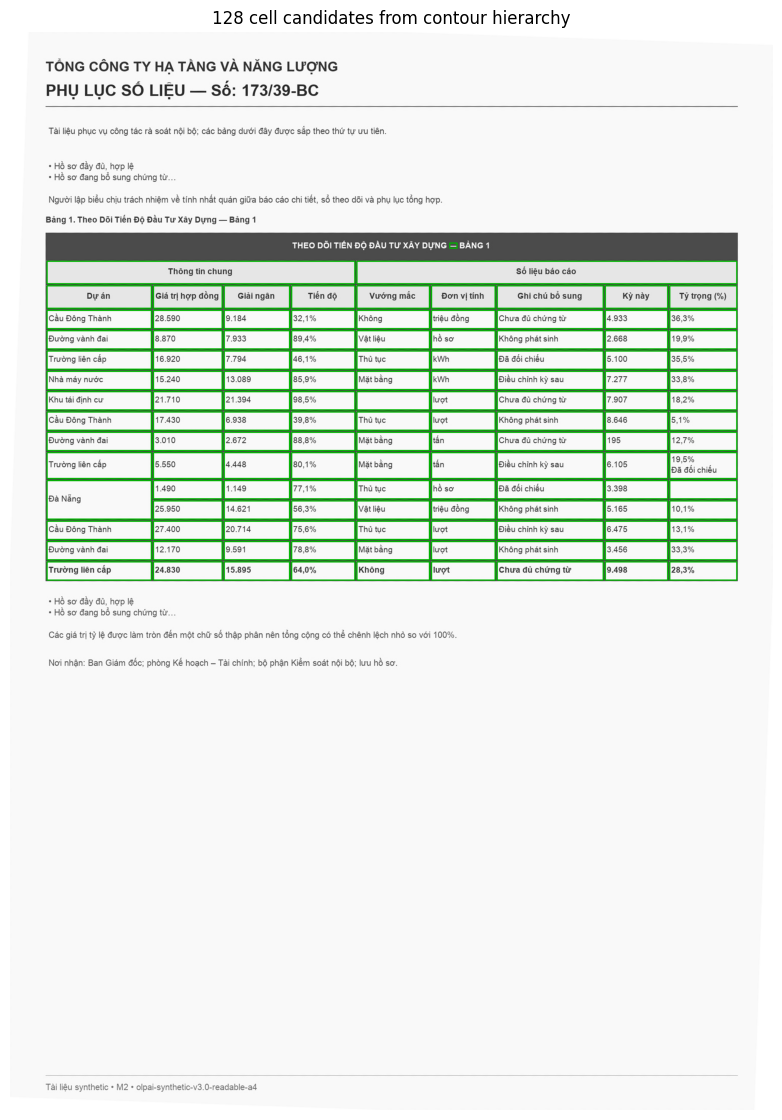

Cell bounding boxes: [(1037, 498, 1054, 510), (87, 541, 813, 594), (818, 541, 1714, 594), (87, 599, 333, 652), (338, 599, 500, 652), (505, 599, 659, 652), (664, 599, 813, 652), (818, 599, 989, 652), (994, 599, 1144, 652), (1149, 599, 1399, 652), (1404, 599, 1551, 652), (1556, 599, 1714, 652), (87, 657, 333, 700), (338, 657, 500, 700), (505, 657, 659, 700), (664, 657, 813, 700), (818, 657, 989, 700), (994, 657, 1144, 700), (1149, 657, 1399, 700), (1404, 657, 1551, 700), (1556, 657, 1714, 700), (87, 705, 333, 748), (338, 705, 500, 748), (505, 705, 659, 748), (664, 705, 813, 748), (818, 705, 989, 748), (994, 705, 1144, 748), (1149, 705, 1399, 748), (1404, 705, 1551, 748), (1556, 705, 1714, 748), (87, 753, 333, 796), (338, 753, 500, 796), (505, 753, 659, 796), (664, 753, 813, 796), (818, 753, 989, 796), (994, 753, 1144, 796), (1149, 753, 1399, 796), (1404, 753, 1551, 796), (1556, 753, 1714, 796), (87, 801, 333, 844), (338, 801, 500, 844), (505, 801, 659, 844), (664, 801, 813, 844), (818, 8

In [13]:
tree_contours, hierarchy = cv2.findContours(joined, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
assert hierarchy is not None
hierarchy = hierarchy[0]

table_box = boxes[0]
table_rect = (table_box[0], table_box[1], table_box[2] - table_box[0], table_box[3] - table_box[1])
table_index = next(
    index for index, contour in enumerate(tree_contours)
    if cv2.boundingRect(contour) == table_rect
)

cell_boxes_from_contours = []
child = hierarchy[table_index][2]
while child != -1:
    x, y, w, h = cv2.boundingRect(tree_contours[child])
    if w >= 15 and h >= 10:
        cell_boxes_from_contours.append((x, y, x + w, y + h))
    child = hierarchy[child][0]

cell_boxes_from_contours.sort(key=lambda box: (box[1], box[0]))
cell_overlay = cv2.cvtColor(deskewed, cv2.COLOR_GRAY2RGB)
for x0, y0, x1, y1 in cell_boxes_from_contours:
    cv2.rectangle(cell_overlay, (x0, y0), (x1, y1), (0, 180, 0), 2)

plt.figure(figsize=(12, 14))
plt.imshow(cell_overlay)
plt.title(f'{len(cell_boxes_from_contours)} cell candidates from contour hierarchy')
plt.axis('off')
plt.show()
print('Cell bounding boxes:', cell_boxes_from_contours)

## 7. Tìm `x_edges` và `y_edges`

Đếm lượng pixel đường kẻ tại từng tọa độ; các đỉnh projection chính là vị trí biên.

x_edges: [84, 335, 502, 661, 815, 991, 1146, 1401, 1553, 1716]
y_edges: [506, 596, 654, 702, 750, 798, 846, 894, 942, 990, 1056, 1104, 1152, 1200, 1248, 1296]
Suy ra 15 hàng × 9 cột


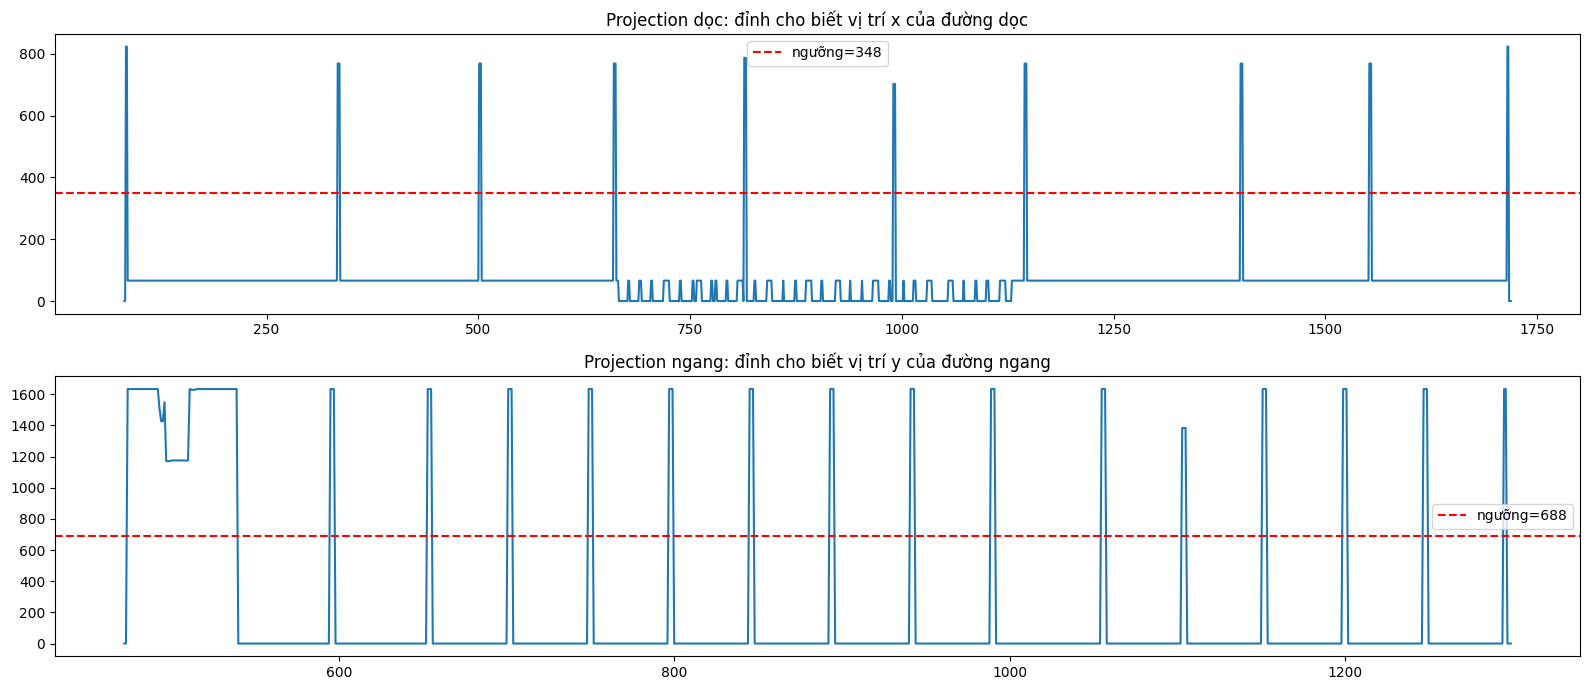

In [14]:
def runs(mask, gap=3):
    indices = np.flatnonzero(mask)
    if not len(indices): return []
    groups, start, previous = [], int(indices[0]), int(indices[0])
    for value in map(int, indices[1:]):
        if value - previous > gap:
            groups.append((start, previous))
            start = value
        previous = value
    return groups + [(start, previous)]

def line_positions(mask, axis, extent):
    projection = np.count_nonzero(mask, axis=axis)
    threshold = max(8, round(extent * 0.42))
    positions = [round((start + end) / 2) for start, end in runs(projection >= threshold)]
    return positions, projection, threshold

x0, y0, x1, y1 = boxes[0]
local_h = horizontal[y0:y1, x0:x1]
local_v = vertical[y0:y1, x0:x1]
xs, vertical_projection, x_threshold = line_positions(local_v, axis=0, extent=y1 - y0)
ys, horizontal_projection, y_threshold = line_positions(local_h, axis=1, extent=x1 - x0)
x_edges = [x0 + value for value in xs]
y_edges = [y0 + value for value in ys]

print('x_edges:', x_edges)
print('y_edges:', y_edges)
print(f'Suy ra {len(y_edges)-1} hàng × {len(x_edges)-1} cột')

fig, axes = plt.subplots(2, 1, figsize=(16, 7))
axes[0].plot(np.arange(x0, x1), vertical_projection)
axes[0].axhline(x_threshold, color='red', linestyle='--', label=f'ngưỡng={x_threshold}')
axes[0].set_title('Projection dọc: đỉnh cho biết vị trí x của đường dọc')
axes[0].legend()
axes[1].plot(np.arange(y0, y1), horizontal_projection)
axes[1].axhline(y_threshold, color='red', linestyle='--', label=f'ngưỡng={y_threshold}')
axes[1].set_title('Projection ngang: đỉnh cho biết vị trí y của đường ngang')
axes[1].legend()
plt.tight_layout()
plt.show()

### 7.1. Validate contour candidates against the label

Compare both the logical-cell count and the grid shape. Equal counts alone can hide one missing cell and one false positive.

In [15]:
label_rows = []
for line in label_path.read_text(encoding='utf-8').splitlines():
    if not line.strip().startswith('|'):
        continue
    cells = [cell.strip() for cell in line.strip().strip('|').split('|')]
    if not all(not cell.strip(' :-') for cell in cells):
        label_rows.append(cells)

assert label_rows and len({len(row) for row in label_rows}) == 1
label_shape = (len(label_rows), len(label_rows[0]))
detected_shape = (len(y_edges) - 1, len(x_edges) - 1)
logical_cell_count = sum(
    cell not in {'[[H]]', '[[V]]'} for row in label_rows for cell in row
)
contour_count = len(cell_boxes_from_contours)

print('Label grid shape       :', label_shape)
print('Detected grid shape    :', detected_shape)
print('Label logical cells    :', logical_cell_count)
print('Contour cell candidates:', contour_count)
print('Grid shape match       :', detected_shape == label_shape)
print('Cell count match       :', contour_count == logical_cell_count)
if contour_count == logical_cell_count and detected_shape != label_shape:
    print('WARNING: matching counts are accidental; inspect missing and false-positive contours.')

Label grid shape       : (16, 9)
Detected grid shape    : (15, 9)
Label logical cells    : 128
Contour cell candidates: 128
Grid shape match       : False
Cell count match       : True


## 8. Vẽ lưới lên ảnh

Đường xanh là biên cột, đường đỏ là biên hàng mà baseline sẽ dùng để cắt ô.

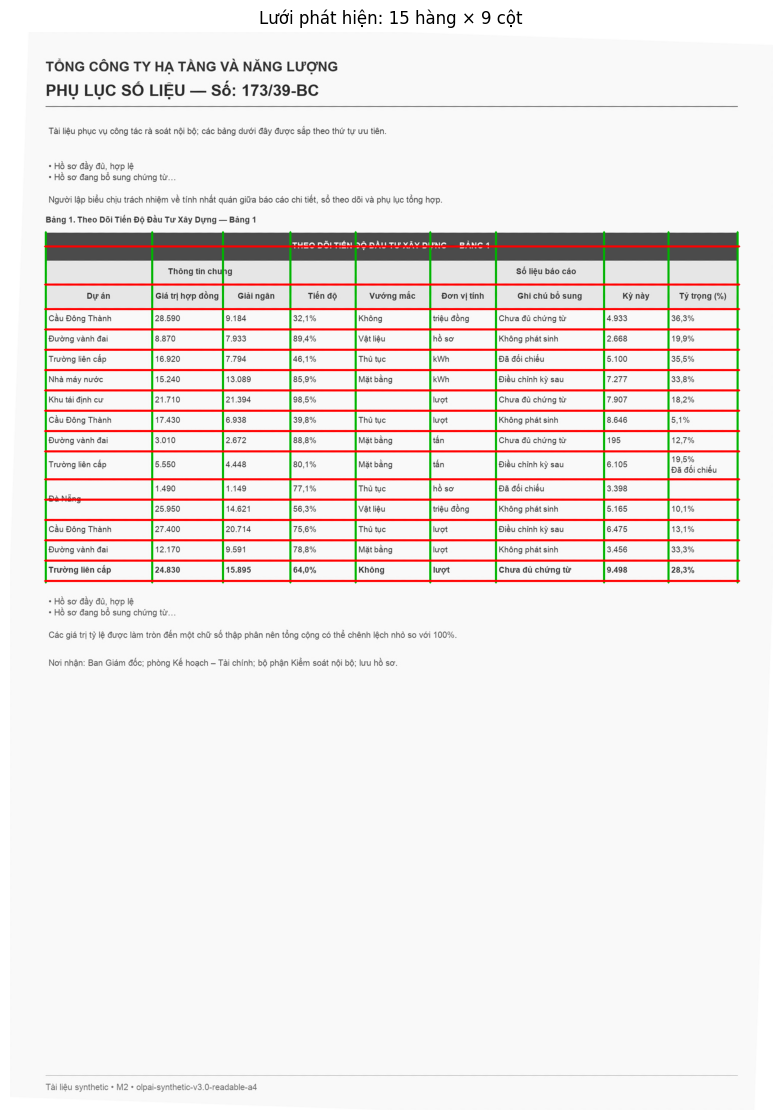

In [16]:
grid_overlay = cv2.cvtColor(deskewed, cv2.COLOR_GRAY2RGB)
for x in x_edges:
    cv2.line(grid_overlay, (x, y0), (x, y1), (0, 180, 0), 4)
for y in y_edges:
    cv2.line(grid_overlay, (x0, y), (x1, y), (255, 0, 0), 4)

plt.figure(figsize=(12, 14))
plt.imshow(grid_overlay)
plt.title(f'Lưới phát hiện: {len(y_edges)-1} hàng × {len(x_edges)-1} cột')
plt.axis('off')
plt.show()

## 9. Cắt từng ô

Mỗi cặp biên liên tiếp tạo một crop; baseline đưa các crop này vào mô hình OCR.

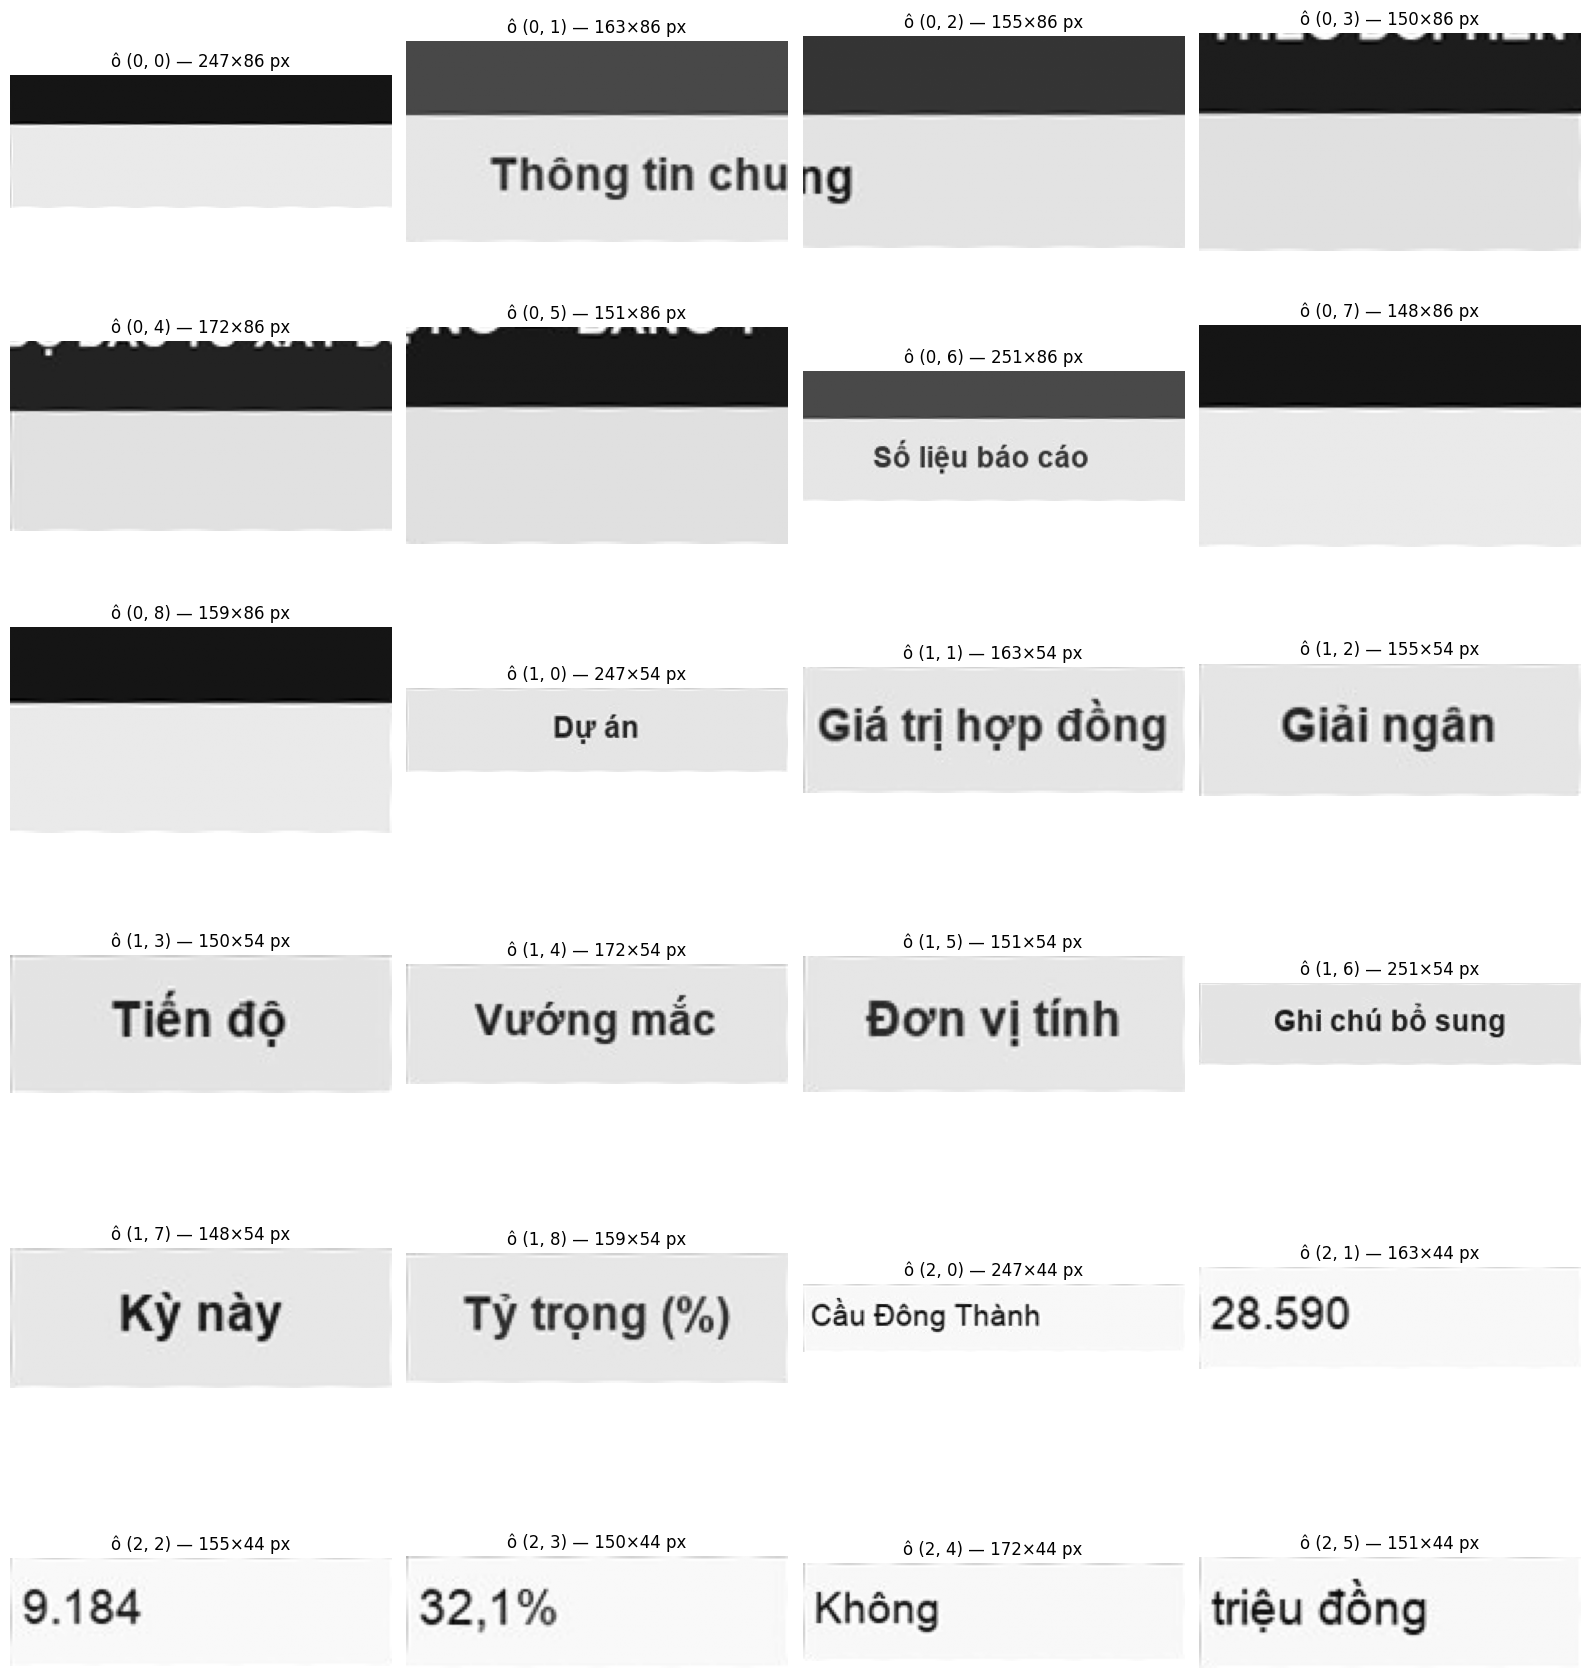

Có tổng cộng 135 crop; hình chỉ hiển thị 24 crop đầu.


In [17]:
cell_crops = []
for row in range(len(y_edges) - 1):
    for col in range(len(x_edges) - 1):
        left, right = x_edges[col] + 2, x_edges[col + 1] - 2
        top, bottom = y_edges[row] + 2, y_edges[row + 1] - 2
        cell_crops.append((row, col, deskewed[top:bottom, left:right]))

shown = cell_crops[:min(24, len(cell_crops))]
columns = min(4, len(shown))
rows = int(np.ceil(len(shown) / columns))
fig, axes = plt.subplots(rows, columns, figsize=(16, 3 * rows), squeeze=False)
for ax in axes.ravel(): ax.axis('off')
for ax, (row, col, crop) in zip(axes.ravel(), shown):
    ax.imshow(crop, cmap='gray')
    ax.set_title(f'ô ({row}, {col}) — {crop.shape[1]}×{crop.shape[0]} px')
plt.tight_layout()
plt.show()
print(f'Có tổng cộng {len(cell_crops)} crop; hình chỉ hiển thị {len(shown)} crop đầu.')

## 10. Thử M2 và quan sát giới hạn

Đổi `SAMPLE_ID` thành `train-00300`, chạy lại từ đầu và nhìn các đường lưới đi qua tiêu đề gộp.

### Câu hỏi quan sát

- `x_edges/y_edges` có đúng với lưới cơ sở không?
- Một tiêu đề gộp có bị chia thành nhiều crop không?
- Crop nào chứa nhiều dòng văn bản?
- Vì sao ô rỗng không thể tự động coi là `[[H]]` hoặc `[[V]]`?

### Kết luận

Với M1, tìm đúng lưới gần như hoàn thành phần cấu trúc. Với M2, lưới chỉ là đầu vào để tiếp tục suy luận ô gộp. Các bước dưới đây phục hồi logical cells trước khi OCR.

### 10.1. Sửa thick run để lấy đủ biên hàng

Hàm projection phía trên luôn lấy tâm của mỗi run. Cách này đúng với đường kẻ mảnh, nhưng dark title band của M2 tạo một run dày: hai mép của run mới là hai biên hàng. Ta in từng run trước, rồi áp dụng đúng hai quy tắc: run mảnh lấy tâm, run dày giữ cả hai mép.

Các horizontal projection runs:
     2..  67 | dày 66 px | giữ hai mép
   123.. 125 | dày  3 px | lấy tâm
   181.. 183 | dày  3 px | lấy tâm
   229.. 231 | dày  3 px | lấy tâm
   277.. 279 | dày  3 px | lấy tâm
   325.. 327 | dày  3 px | lấy tâm
   373.. 375 | dày  3 px | lấy tâm
   421.. 423 | dày  3 px | lấy tâm
   469.. 471 | dày  3 px | lấy tâm
   517.. 519 | dày  3 px | lấy tâm
   583.. 585 | dày  3 px | lấy tâm
   631.. 633 | dày  3 px | lấy tâm
   679.. 681 | dày  3 px | lấy tâm
   727.. 729 | dày  3 px | lấy tâm
   775.. 777 | dày  3 px | lấy tâm
   823.. 824 | dày  2 px | lấy tâm

Trước khi xử lý thick run: 15 hàng × 9 cột
Sau khi xử lý thick run : 16 hàng × 9 cột
Nhãn chuẩn               : 16 hàng × 9 cột


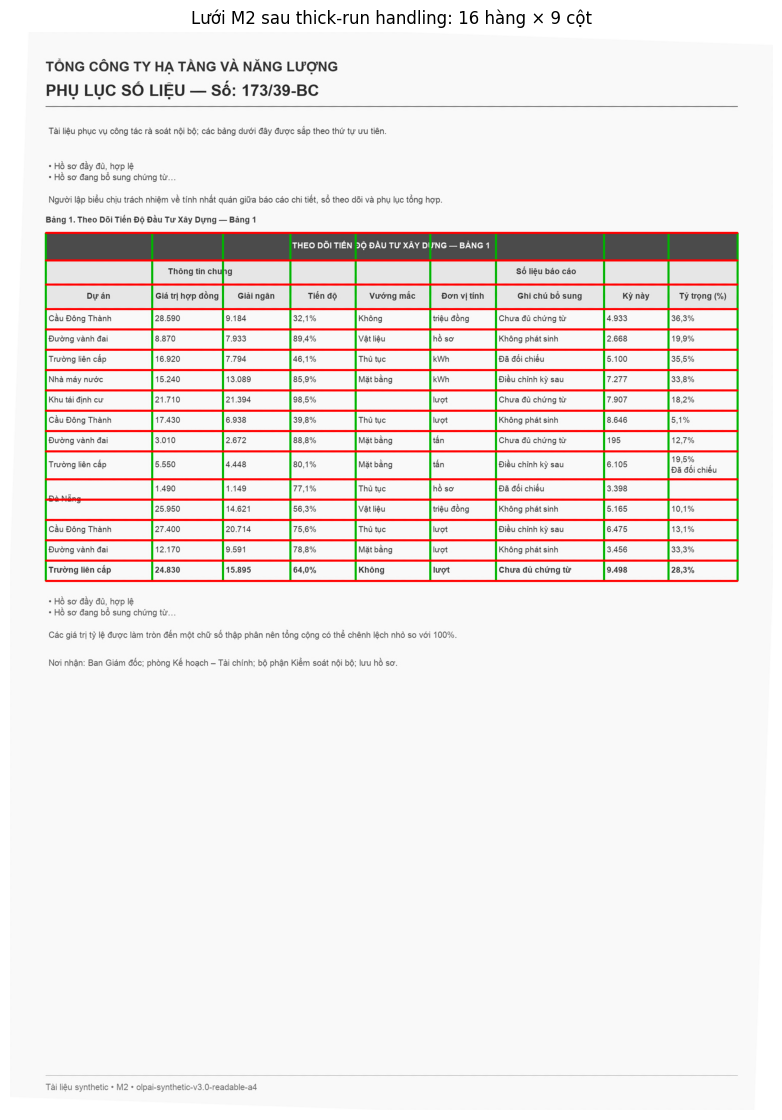

In [18]:
def dedupe(values, tolerance=6):
    groups = []
    for value in sorted(values):
        if not groups or value - groups[-1][-1] > tolerance:
            groups.append([value])
        else:
            groups[-1].append(value)
    return [round(sum(group) / len(group)) for group in groups]

def line_positions_m2(mask, axis, extent, thick_width=10):
    projection = np.count_nonzero(mask, axis=axis)
    threshold = max(8, round(extent * 0.42))
    detected_runs = runs(projection >= threshold)
    positions = []
    for start, end in detected_runs:
        width_px = end - start + 1
        positions.extend((start, end) if width_px >= thick_width else [round((start + end) / 2)])
    return positions, projection, threshold, detected_runs

xs_m2, vertical_projection_m2, _, x_runs = line_positions_m2(local_v, axis=0, extent=y1 - y0)
ys_m2, horizontal_projection_m2, _, y_runs = line_positions_m2(local_h, axis=1, extent=x1 - x0)

print('Các horizontal projection runs:')
for start, end in y_runs:
    width_px = end - start + 1
    rule = 'giữ hai mép' if width_px >= 10 else 'lấy tâm'
    print(f'  {start:4d}..{end:4d} | dày {width_px:2d} px | {rule}')

x_edges_m2 = dedupe([x0 + value for value in xs_m2])
y_edges_m2 = dedupe([y0 + value for value in ys_m2])

print(f'\nTrước khi xử lý thick run: {len(y_edges)-1} hàng × {len(x_edges)-1} cột')
print(f'Sau khi xử lý thick run : {len(y_edges_m2)-1} hàng × {len(x_edges_m2)-1} cột')
print('Nhãn chuẩn               :', label_shape[0], 'hàng ×', label_shape[1], 'cột')
assert (len(y_edges_m2) - 1, len(x_edges_m2) - 1) == label_shape

m2_grid_overlay = cv2.cvtColor(deskewed, cv2.COLOR_GRAY2RGB)
for x in x_edges_m2:
    cv2.line(m2_grid_overlay, (x, y_edges_m2[0]), (x, y_edges_m2[-1]), (0, 180, 0), 3)
for y in y_edges_m2:
    cv2.line(m2_grid_overlay, (x_edges_m2[0], y), (x_edges_m2[-1], y), (255, 0, 0), 3)

plt.figure(figsize=(12, 14))
plt.imshow(m2_grid_overlay)
plt.title(f'Lưới M2 sau thick-run handling: {len(y_edges_m2)-1} hàng × {len(x_edges_m2)-1} cột')
plt.axis('off')
plt.show()

### 10.2. Tạo atomic grid và nhận diện M2

Grid đúng vẫn chỉ tạo ra các atomic cells. CellRegion sẽ được bổ sung sau để mô tả nhiều atomic cells thuộc cùng một logical cell. Chỉ số kết thúc row1/col1 là exclusive, giống Python slicing.

In [19]:
from dataclasses import dataclass

@dataclass(frozen=True)
class CellRegion:
    row0: int
    row1: int
    col0: int
    col1: int

@dataclass(frozen=True)
class GridTable:
    bbox: tuple
    x_edges: tuple
    y_edges: tuple
    regions: tuple = ()

    @property
    def rows(self):
        return len(self.y_edges) - 1

    @property
    def cols(self):
        return len(self.x_edges) - 1

def is_m2_table(table):
    if table.cols >= 8:
        return True, f'{table.cols} cột (M2 có ít nhất 8 cột)'
    if table.cols != 7 or table.rows < 3:
        return False, 'geometry không khớp grammar M2'
    heights = np.diff(table.y_edges)
    ratio = heights[0] / max(1.0, float(np.median(heights[2:])))
    return ratio >= 1.30, f'tỷ lệ chiều cao row đầu = {ratio:.2f}'

atomic_table = GridTable(
    bbox=(x_edges_m2[0], y_edges_m2[0], x_edges_m2[-1], y_edges_m2[-1]),
    x_edges=tuple(x_edges_m2),
    y_edges=tuple(y_edges_m2),
)
is_m2, m2_reason = is_m2_table(atomic_table)

print(f'Atomic grid : {atomic_table.rows} hàng × {atomic_table.cols} cột')
print(f'Atomic cells: {atomic_table.rows * atomic_table.cols}')
print('Loại bảng  :', 'M2' if is_m2 else 'không phải M2')
print('Lý do      :', m2_reason)
assert is_m2

Atomic grid : 16 hàng × 9 cột
Atomic cells: 144
Loại bảng  : M2
Lý do      : 9 cột (M2 có ít nhất 8 cột)


### 10.3. Horizontal merge theo grammar M2

Baseline chưa suy luận horizontal merge tổng quát từ vertical mask. Với M2, EDA cho biết row 0 là title span toàn bảng; row 1 gồm hai grouped headers. Hình dưới chỉ minh họa grammar, chưa chạy union-find.

Title: toàn bộ row 0: rows [0, 1), cols [0, 9)
Header group trái: rows [1, 2), cols [0, 4)
Header group phải: rows [1, 2), cols [4, 9)


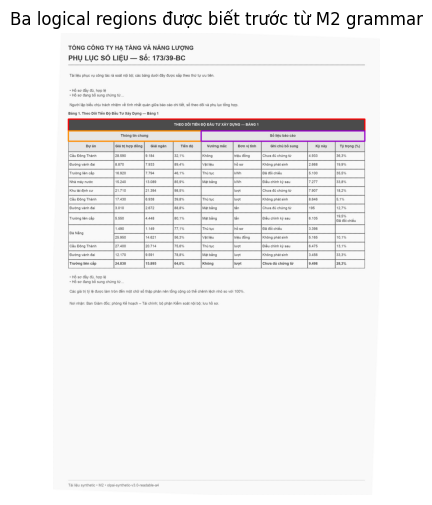

In [20]:
split_col = atomic_table.cols // 2
grammar_overlay = cv2.cvtColor(deskewed, cv2.COLOR_GRAY2RGB)

grammar_regions = [
    ('Title: toàn bộ row 0', CellRegion(0, 1, 0, atomic_table.cols), (255, 0, 0)),
    ('Header group trái', CellRegion(1, 2, 0, split_col), (255, 140, 0)),
    ('Header group phải', CellRegion(1, 2, split_col, atomic_table.cols), (150, 0, 200)),
]

for label, region, color in grammar_regions:
    left, right = atomic_table.x_edges[region.col0], atomic_table.x_edges[region.col1]
    top, bottom = atomic_table.y_edges[region.row0], atomic_table.y_edges[region.row1]
    cv2.rectangle(grammar_overlay, (left, top), (right, bottom), color, 5)
    print(f'{label}: rows [{region.row0}, {region.row1}), cols [{region.col0}, {region.col1})')

plt.figure(figsize=(14, 6))
plt.imshow(grammar_overlay)
plt.title('Ba logical regions được biết trước từ M2 grammar')
plt.axis('off')
plt.show()

### 10.4. Đo local separator bằng segment coverage

Projection đã tìm global y-edges, nhưng một horizontal separator có thể bị thiếu trong riêng một cột. Ta lấy một strip quanh boundary, trim hai đầu để bỏ vertical borders, rồi đo tỷ lệ chiều ngang có line evidence. Coverage thấp hơn 20% trở thành vertical-merge candidate.

Tìm thấy 1 vertical-merge candidates:
  rows 11–12, col 0: coverage=0.000 < 0.20


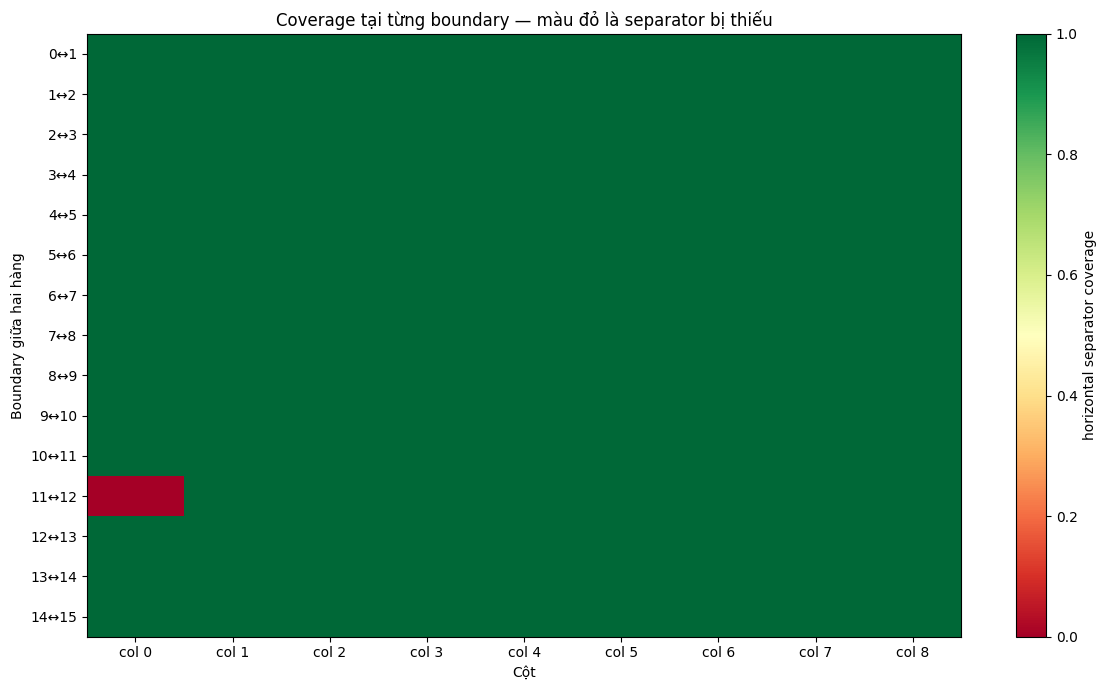

In [21]:
def horizontal_segment_coverage(mask, y, left, right, radius=2, trim=3):
    left, right = left + trim, right - trim
    if right <= left:
        return 1.0
    band = mask[max(0, y-radius):min(mask.shape[0], y+radius+1), left:right]
    return float(np.any(band > 0, axis=0).mean())

coverage_map = np.ones((atomic_table.rows - 1, atomic_table.cols), dtype=float)
vertical_merge_candidates = []
for row in range(atomic_table.rows - 1):
    boundary_y = atomic_table.y_edges[row + 1]
    for col in range(atomic_table.cols):
        coverage = horizontal_segment_coverage(
            horizontal,
            boundary_y,
            atomic_table.x_edges[col],
            atomic_table.x_edges[col + 1],
        )
        coverage_map[row, col] = coverage
        if coverage < 0.20:
            vertical_merge_candidates.append((row, row + 1, col, coverage))

print(f'Tìm thấy {len(vertical_merge_candidates)} vertical-merge candidates:')
for row0, row1, col, coverage in vertical_merge_candidates:
    print(f'  rows {row0}–{row1}, col {col}: coverage={coverage:.3f} < 0.20')

plt.figure(figsize=(12, 7))
plt.imshow(coverage_map, cmap='RdYlGn', vmin=0, vmax=1, aspect='auto')
plt.colorbar(label='horizontal separator coverage')
plt.xticks(range(atomic_table.cols), [f'col {col}' for col in range(atomic_table.cols)])
plt.yticks(range(atomic_table.rows - 1), [f'{row}↔{row+1}' for row in range(atomic_table.rows - 1)])
plt.title('Coverage tại từng boundary — màu đỏ là separator bị thiếu')
plt.xlabel('Cột')
plt.ylabel('Boundary giữa hai hàng')
plt.tight_layout()
plt.show()

### 10.5. Gom atomic cells bằng union-find

Union-find không tự phát hiện merge. Nó chỉ gom các cặp đã có evidence từ M2 grammar hoặc segment coverage. Sau cùng, mỗi connected component hình chữ nhật được chuyển thành một CellRegion.

In [22]:
def infer_m2_regions(table, coverage_map, merge_threshold=0.20):
    parent = list(range(table.rows * table.cols))
    merge_log = []

    def node(row, col):
        return row * table.cols + col

    def find(value):
        while parent[value] != value:
            parent[value] = parent[parent[value]]
            value = parent[value]
        return value

    def union(left, right, reason):
        left_root, right_root = find(left), find(right)
        if left_root != right_root:
            parent[right_root] = left_root
            merge_log.append(reason)

    split = table.cols // 2
    for col in range(table.cols - 1):
        union(node(0, col), node(0, col + 1), 'M2 title grammar')
    for col in range(split - 1):
        union(node(1, col), node(1, col + 1), 'M2 left header grammar')
    for col in range(split, table.cols - 1):
        union(node(1, col), node(1, col + 1), 'M2 right header grammar')

    for row in range(table.rows - 1):
        for col in range(table.cols):
            if coverage_map[row, col] < merge_threshold:
                union(node(row, col), node(row + 1, col), f'missing separator r{row}↔r{row+1}, c{col}')

    components = {}
    for row in range(table.rows):
        for col in range(table.cols):
            components.setdefault(find(node(row, col)), []).append((row, col))

    regions = []
    for members in components.values():
        member_rows, member_cols = zip(*members)
        row0, row1 = min(member_rows), max(member_rows) + 1
        col0, col1 = min(member_cols), max(member_cols) + 1
        if len(members) == (row1 - row0) * (col1 - col0):
            regions.append(CellRegion(row0, row1, col0, col1))
        else:
            regions.extend(CellRegion(row, row + 1, col, col + 1) for row, col in members)

    return tuple(sorted(regions, key=lambda region: (region.row0, region.col0))), merge_log

logical_regions, merge_log = infer_m2_regions(atomic_table, coverage_map)
m2_table = GridTable(atomic_table.bbox, atomic_table.x_edges, atomic_table.y_edges, logical_regions)
merged_regions = [region for region in logical_regions if region.row1-region.row0 > 1 or region.col1-region.col0 > 1]

print('Atomic cells       :', atomic_table.rows * atomic_table.cols)
print('Logical regions    :', len(logical_regions))
print('Nhãn logical cells :', logical_cell_count)
print('Union operations   :', len(merge_log))
print('\nCác merged CellRegion:')
for region in merged_regions:
    print(' ', region)

assert len(logical_regions) == logical_cell_count

Atomic cells       : 144
Logical regions    : 128
Nhãn logical cells : 128
Union operations   : 16

Các merged CellRegion:
  CellRegion(row0=0, row1=1, col0=0, col1=9)
  CellRegion(row0=1, row1=2, col0=0, col1=4)
  CellRegion(row0=1, row1=2, col0=4, col1=9)
  CellRegion(row0=11, row1=13, col0=0, col1=1)


### 10.6. Vẽ logical CellRegions

Nét xanh mảnh là normal cell. Nét đỏ dày là merged logical cell; nhãn đỏ ghi anchor của region. Hình này cho thấy atomic edges vẫn được giữ nguyên, còn CellRegion bổ sung grouping semantics.

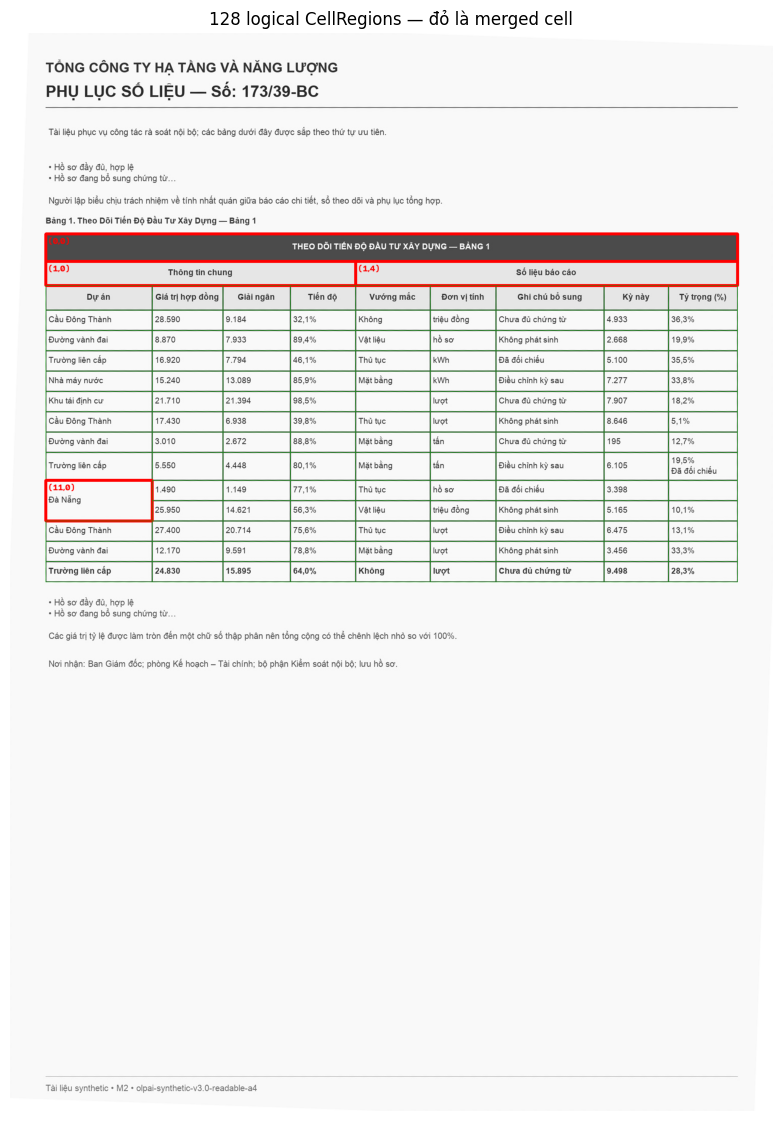

In [23]:
logical_overlay = cv2.cvtColor(deskewed, cv2.COLOR_GRAY2RGB)
for region in logical_regions:
    left, right = m2_table.x_edges[region.col0], m2_table.x_edges[region.col1]
    top, bottom = m2_table.y_edges[region.row0], m2_table.y_edges[region.row1]
    is_merged = region.row1-region.row0 > 1 or region.col1-region.col0 > 1
    color = (255, 0, 0) if is_merged else (0, 170, 0)
    thickness = 5 if is_merged else 1
    cv2.rectangle(logical_overlay, (left, top), (right, bottom), color, thickness)
    if is_merged:
        cv2.putText(logical_overlay, f'({region.row0},{region.col0})', (left+5, top+24), cv2.FONT_HERSHEY_SIMPLEX, 0.65, color, 2)

plt.figure(figsize=(12, 14))
plt.imshow(logical_overlay)
plt.title(f'{len(logical_regions)} logical CellRegions — đỏ là merged cell')
plt.axis('off')
plt.show()

### 10.7. Tạo anchor, [[H]] và [[V]]

Vị trí trên-trái của mỗi CellRegion là anchor để sau này giữ OCR text. Các vị trí còn lại trên cùng hàng nhận [[H]]; các vị trí ở hàng thấp hơn nhận [[V]]. Label chỉ được dùng ở đây để kiểm tra kết quả, không tham gia inference.

In [24]:
def merge_markers(table):
    cells = [['' for _ in range(table.cols)] for _ in range(table.rows)]
    for region in table.regions:
        for row in range(region.row0, region.row1):
            for col in range(region.col0, region.col1):
                if (row, col) != (region.row0, region.col0):
                    cells[row][col] = '[[H]]' if row == region.row0 else '[[V]]'
    return cells

marker_grid = merge_markers(m2_table)
predicted_markers = {(row, col, value) for row, values in enumerate(marker_grid) for col, value in enumerate(values) if value}
label_markers = {(row, col, value) for row, values in enumerate(label_rows) for col, value in enumerate(values) if value in {'[[H]]', '[[V]]'}}

print('Ba header rows (ANCHOR là nơi sẽ chứa OCR text):')
for row in range(3):
    shown = [value or 'ANCHOR' for value in marker_grid[row]]
    print(f'row {row:2d}:', ' | '.join(shown))

vertical_regions = [region for region in merged_regions if region.row1-region.row0 > 1]
print('\nVertical merged regions:')
for region in vertical_regions:
    print(' ', region, '→ anchor ở', (region.row0, region.col0), ', continuation [[V]] ở các hàng dưới')

print('\nMarker positions predicted:', len(predicted_markers))
print('Marker positions expected :', len(label_markers))
print('Khớp hoàn toàn            :', predicted_markers == label_markers)
if predicted_markers != label_markers:
    print('Thiếu:', sorted(label_markers - predicted_markers))
    print('Thừa :', sorted(predicted_markers - label_markers))
assert predicted_markers == label_markers

Ba header rows (ANCHOR là nơi sẽ chứa OCR text):
row  0: ANCHOR | [[H]] | [[H]] | [[H]] | [[H]] | [[H]] | [[H]] | [[H]] | [[H]]
row  1: ANCHOR | [[H]] | [[H]] | [[H]] | ANCHOR | [[H]] | [[H]] | [[H]] | [[H]]
row  2: ANCHOR | ANCHOR | ANCHOR | ANCHOR | ANCHOR | ANCHOR | ANCHOR | ANCHOR | ANCHOR

Vertical merged regions:
  CellRegion(row0=11, row1=13, col0=0, col1=1) → anchor ở (11, 0) , continuation [[V]] ở các hàng dưới

Marker positions predicted: 16
Marker positions expected : 16
Khớp hoàn toàn            : True


### 10.8. Crop logical cells thay vì atomic cells

Mỗi CellRegion chỉ tạo một crop. Vì vậy title, grouped headers và ô Đà Nẵng được giữ nguyên thành các vùng lớn; continuation positions không bị OCR lặp lại.

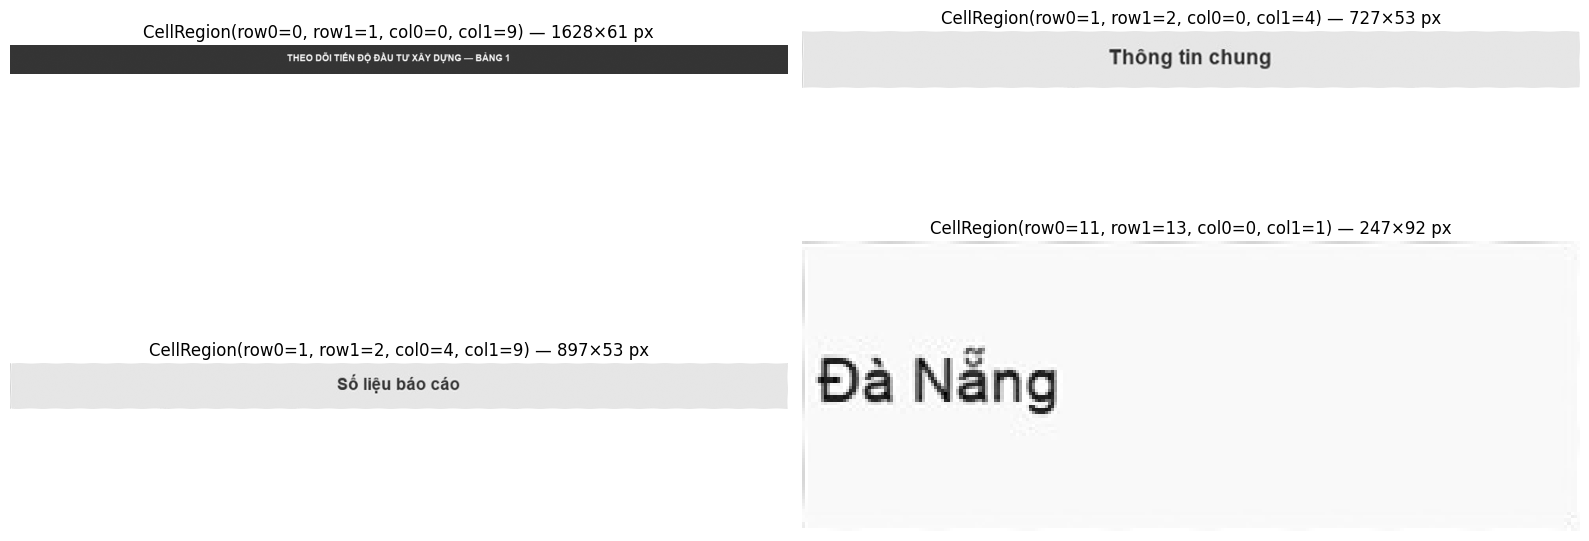

Atomic crops ban đầu: 144
Logical crops cho OCR: 128
Giảm OCR lặp lại      : 16 crop


In [25]:
logical_crops = []
for region in logical_regions:
    left, right = m2_table.x_edges[region.col0] + 2, m2_table.x_edges[region.col1] - 2
    top, bottom = m2_table.y_edges[region.row0] + 2, m2_table.y_edges[region.row1] - 2
    logical_crops.append((region, deskewed[top:bottom, left:right]))

interesting = [(region, crop) for region, crop in logical_crops if region in merged_regions]
columns = min(2, len(interesting))
rows = int(np.ceil(len(interesting) / columns))
fig, axes = plt.subplots(rows, columns, figsize=(16, 4 * rows), squeeze=False)
for ax in axes.ravel():
    ax.axis('off')
for ax, (region, crop) in zip(axes.ravel(), interesting):
    ax.imshow(crop, cmap='gray')
    ax.set_title(f'{region} — {crop.shape[1]}×{crop.shape[0]} px')
plt.tight_layout()
plt.show()

print('Atomic crops ban đầu:', atomic_table.rows * atomic_table.cols)
print('Logical crops cho OCR:', len(logical_crops))
print('Giảm OCR lặp lại      :', atomic_table.rows * atomic_table.cols - len(logical_crops), 'crop')

### Kết luận M2 reconstruction

M2 cần hai lớp suy luận sau projection: thick-run handling phục hồi đúng atomic grid; M2 grammar kết hợp local segment coverage gom atomic cells thành logical CellRegions. OCR chỉ nên chạy sau bước này, một lần tại anchor của mỗi logical region.

Giới hạn hiện tại: horizontal merge ngoài hai header rows vẫn dựa trên grammar M2, chưa dùng vertical-mask coverage để suy luận tổng quát.